In [ ]:
pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 17.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing inst

In [ ]:
import math
import random
from datetime import datetime, timedelta
from typing import List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas_ta as ta

In [ ]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.4 MB/s eta 0:00:00


In [ ]:
# Install and import PyG modules separately; user must have torch-geometric installed.
try:
    from torch_geometric.nn import GCNConv
except Exception as e:
    raise ImportError("Please install torch-geometric following the official instructions. Error: " + str(e))

# Transformers FinBERT
from transformers import pipeline

# yfinance for price data
import yfinance as yf

### Apple

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

apple_data = pd.read_excel(r"/content/gdrive/My Drive/Dataset/News_Info.xlsx", sheet_name="Apple")
apple_data['date']=pd.to_datetime(apple_data['date']).dt.date

apple_data.dropna(inplace=True)
apple_data

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,Judge grills Apple exec about whether company ...,"OAKLAND, Calif. (AP) — A federal judge on Wedn...",https://finance.yahoo.com/news/judge-grills-ap...,"['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...",[],"{'polarity': 0.956, 'neg': 0.035, 'neu': 0.899..."
1,2024-05-08,Apple’s Unionized Maryland Store to Vote on Po...,(Bloomberg) -- Apple Inc.’s unionized retail s...,https://finance.yahoo.com/news/apple-unionized...,"['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...",[],"{'polarity': -0.902, 'neg': 0.1, 'neu': 0.842,..."
2,2024-05-08,Music streaming firms urge European Commission...,By Jaspreet Singh\n\n(Reuters) - A group that ...,https://finance.yahoo.com/news/music-streaming...,"['0R2V.IL', '639.F', '639.STU', '639.XETRA', '...",[],"{'polarity': 0.055, 'neg': 0.029, 'neu': 0.944..."
3,2024-05-08,The 3 Best Metaverse Stocks to Buy in May 2024,Meta Platforms (NASDAQ:META) is still losing b...,https://finance.yahoo.com/news/3-best-metavers...,"['AAPL.US', 'ELF.US', 'META.US', 'MSFT.US', 'N...",[],"{'polarity': 0.997, 'neg': 0.016, 'neu': 0.884..."
4,2024-05-08,Apple’s iPad event was an AI teaser for its fu...,"Apple’s (AAPL) AI push has begun. On Tuesday, ...",https://finance.yahoo.com/news/apples-ipad-eve...,"['0QYP.IL', '0QZD.LSE', '0QZI.LSE', '0R1O.IL',...",[],"{'polarity': 0.972, 'neg': 0.002, 'neu': 0.943..."
...,...,...,...,...,...,...,...
26745,2018-01-31,Investor Expectations to Drive Momentum within...,"NEW YORK, Jan. 31, 2018 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['AAPL.US', 'AVHI.US', 'FARM.US', 'GM.US', 'SG...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.995, 'neg': 0.009, 'neu': 0.937..."
26746,2017-11-30,"BioTelemetry, Inc. Enters Agreement to Provide...","MALVERN, Pa., Nov. 30, 2017 (GLOBE NEWSWIRE)...",https://www.globenewswire.com/news-release/201...,"['AAPL.US', 'BEAT.US']","['BIOTELEMETRY', 'INC', 'NASDAQ:BEAT']","{'polarity': 0.989, 'neg': 0.021, 'neu': 0.804..."
26747,2017-11-27,"Factors of Influence in 2018, Key Indicators a...","NEW YORK, Nov. 27, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['AAPL.US', 'CSCO.US', 'GD.US', 'HPE.US', 'NVD...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.997, 'neg': 0.008, 'neu': 0.926..."
26748,2017-10-05,New Research: Key Drivers of Growth for Micros...,"NEW YORK, Oct. 05, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['AAPL.US', 'AMZN.US', 'INTC.US', 'MSFT.US', '...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.997, 'neg': 0.008, 'neu': 0.925..."


In [ ]:
import ast
from itertools import chain

def normalize_cell(cell):
    # Return a list for valid inputs, else empty list
    if pd.isna(cell):
        return []
    if isinstance(cell, (list, tuple, set)):
        return list(cell)
    # try to parse string representations like "['AAPL.US','MSFT.US']"
    if isinstance(cell, str):
        try:
            parsed = ast.literal_eval(cell)
            if isinstance(parsed, (list, tuple, set)):
                return list(parsed)
        except Exception:
            pass
        # fallback: if comma-separated ticker string
        if ',' in cell:
            return [s.strip().strip("'\"") for s in cell.split(',') if s.strip()]
    return []

# Apply normalization then flatten to a unique sorted list
all_lists = apple_data['symbols'].apply(normalize_cell)
unique_tickers = sorted(set(chain.from_iterable(all_lists)))

print(f"Total unique tickers: {len(unique_tickers)}")
print(unique_tickers[:200])  # show first 200 tickers (or adjust)

Total unique tickers: 7759
['$ANRX-USD.CC', '$COIN-USD.CC', '$E@DLR-PL.US', '$E@EMCF.US', '$KING-USD.CC', '$ROPE-USD.CC', '000001.SHG', '000063.SHE', '000270.KO', '0005.HK', '000625.SHE', '000636.SHE', '000660.KO', '000660.US', '000681.SHE', '000725.SHE', '000804.SHG', '001200.KO', '002081.SHE', '002241.SHE', '002268.SHE', '002317.SHE', '002415.SHE', '002442.SHE', '002475.SHE', '002497.SHE', '002558.SHE', '002594.SHE', '0027.HK', '002722.SHE', '002846.SHE', '003011.SHE', '003470.KO', '003475.KO', '003490.KO', '003495.KO', '003530.KO', '003535.KO', '005380.KO', '005385.KO', '005387.KO', '005389.KO', '005930.KO', '005930.US', '005935.KO', '006800.KO', '006805.KO', '00680K.KO', '012330.KO', '013A.F', '013A.STU', '013C.F', '016.F', '0175.HK', '0213.HK', '0241.HK', '025K.BE', '0267.HK', '0268.HK', '028260.KO', '02826K.KO', '02B.F', '02M.F', '02M.XETRA', '02Z.F', '030210.KO', '032640.KO', '032830.KO', '034220.KO', '035720.KO', '036570.KO', '0384.HK', '0386.HK', '0388.HK', '039056.TW', '03957

In [ ]:
['000001.SHG', '000063.SHE', '000270.KO', '0005.HK', '000625.SHE', '000636.SHE', '000660.KO', '000660.US', '000681.SHE', '000725.SHE', '000804.SHG', '001200.KO', '002081.SHE', '002241.SHE', '002268.SHE', '002317.SHE', '002415.SHE', '002442.SHE', '002475.SHE', '002497.SHE', '002558.SHE', '002594.SHE', '0027.HK', '002722.SHE', '002846.SHE', '003011.SHE', '003470.KO', '003475.KO', '003490.KO', '003495.KO', '003530.KO', '003535.KO', '005380.KO', '005385.KO', '005387.KO', '005389.KO', '005930.KO', '005930.US', '005935.KO', '006800.KO', '006805.KO', '00680K.KO', '012330.KO', '013A.F', '013A.STU', '013C.F', '016.F', '0175.HK', '0213.HK', '0241.HK', '025K.BE', '0267.HK', '0268.HK', '028260.KO', '02826K.KO', '02B.F', '02M.F', '02M.XETRA', '02Z.F', '030210.KO', '032640.KO', '032830.KO', '034220.KO', '035720.KO', '036570.KO', '0384.HK', '0386.HK', '0388.HK', '039056.TW', '039570.KO', '03OA.BE', '03OK.BE', '03OV.BE', '03OV.DU', '040041.TW', '040300.KQ', '0425.HK', '049770.KO', '051910.KO', '051915.KO', '055550.KO', '058679.TW', '05M.F', '0665.HK', '066570.KO', '066575.KO', '068270.KO', '06S.F', '0700-HK.HK', '0700.HK', '0728.HK', '0762.HK', '0763.HK', '079A.F', '079A.STU', '07WA.F', '0813.HK', '0836.HK', '0857.HK', '0883.HK', '0895B.NX', '0939.HK', '0941.HK', '0954B.NX', '096.F', '096.STU', '0960.HK', '0981.HK', '0992.HK', '0A1U.IL', '0A3M.IL', '0BOE.LSE', '0C6.F', '0C6.STU', '0C8.F', '0CG.F', '0CG.STU', '0DF3.BE', '0E7A.DU', '0EAQ.LSE', '0EF.F', '0EF.STU', '0ET.F', '0GS.F', '0GS.STU', '0H4A.LSE', '0H6E.LSE', '0HAF.LSE', '0HAI.LSE', '0HAQ.LSE', '0HC3.LSE', '0HC7.LSE', '0HCI.LSE', '0HD6.IL', '0HEU.LSE', '0HEW.LSE', '0HF3.LSE', '0HF6.LSE', '0HFB.LSE', '0HFN.LSE', '0HG3.LSE', '0HJF.LSE', '0HJI.LSE', '0HJL.LSE', '0HKE.LSE', '0HKP.LSE', '0HLQ.LSE', '0HMZ.LSE', '0HOY.LSE', '0HQ3.LSE', '0HQW.LSE', '0HRJ.LSE', '0HRS.LSE', '0HS2.LSE', '0HTG.LSE', '0HTQ.LSE', '0HW4.LSE', '0I3I.LSE', '0I47.LSE', '0I4W.LSE', '0I58.LSE', '0I77.LSE', '0I7E.LSE', '0I8W.LSE', '0IBC.LSE', '0IC8.LSE', '0IDR.LSE', '0IFX.LSE', '0II3.LSE', '0IIF.IL', '0IIF.LSE', '0IJW.LSE', '0IL6.LSE', '0ILW.LSE', '0IQK.LSE', '0IR9.LSE', '0IUC.LSE', '0IUX.LSE', '0J2E.LSE', '0J2X.XETRA', '0J46.LSE', '0J4X.LSE', '0J51.LSE', '0J6Z.LSE', '0J8P.LSE', '0JC3.LSE', '0JCT.LSE', '0JDP.LSE', '0JQQ.LSE', '0JRV.LSE', '0JS0.LSE', '0JS2.LSE', '0JT5.LSE', '0JTT.LSE']

### HSBC

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

apple_data = pd.read_excel(r"/content/gdrive/My Drive/Dataset/News_Info_part2.xlsx", sheet_name="HSBC")
apple_data['date']=pd.to_datetime(apple_data['date']).dt.date

apple_data.dropna(inplace=True)
apple_data

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,HSBC Holdings PLC's Dividend Analysis,Exploring the Sustainability of HSBC Holdings ...,https://finance.yahoo.com/news/hsbc-holdings-p...,"['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...",[],"{'polarity': 0.998, 'neg': 0.014, 'neu': 0.861..."
1,2024-05-06,Top Three UK Dividend Stocks To Watch In May 2024,As the FTSE 100 mirrors a positive trend in gl...,https://finance.yahoo.com/news/top-three-uk-di...,"['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...",[],"{'polarity': 0.998, 'neg': 0.013, 'neu': 0.879..."
2,2024-05-04,Ping An votes against reappointment of HSBC CE...,(Reuters) - HSBC Holdings Plc's biggest Asian ...,https://finance.yahoo.com/news/ping-votes-agai...,"['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...",[],"{'polarity': -0.477, 'neg': 0.044, 'neu': 0.93..."
3,2024-05-04,HSBC Holdings First Quarter 2024 Earnings: Bea...,HSBC Holdings (LON:HSBA) First Quarter 2024 Re...,https://finance.yahoo.com/news/hsbc-holdings-f...,"['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...",[],"{'polarity': 0.776, 'neg': 0.035, 'neu': 0.911..."
4,2024-05-03,3 Foreign Bank Stocks Worth a Look in a Prospe...,Banks across the globe have been continuously ...,https://finance.yahoo.com/news/3-foreign-bank-...,"['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...",[],"{'polarity': 1, 'neg': 0.013, 'neu': 0.852, 'p..."
...,...,...,...,...,...,...,...
1909,2017-10-17,HSBC Holdings plc Sponsored ADR (HSBC) a Buy o...,"Currently, HSBC Holdings plc Sponsored ADR (NY...",https://investorplace.com/2017/10/hsbc-holding...,['HSBC.US'],[],"{'polarity': 0.296, 'neg': 0, 'neu': 0.945, 'p..."
1910,2017-10-10,HSBC Holdings plc Sponsored ADR (HSBC) Rating ...,HSBC Holdings plc Sponsored ADR (NYSE:HSBC) is...,https://investorplace.com/2017/10/hsbc-holding...,['HSBC.US'],[],"{'polarity': 0.671, 'neg': 0, 'neu': 0.857, 'p..."
1911,2017-09-25,5 Mega-Cap Stocks to Buy with Impressive Growt...,With the U.S. Fed deciding to turn off the qua...,https://investorplace.com/2017/09/5-mega-cap-s...,"['BAYRY.US', 'HSBC.US']",[],"{'polarity': 0.863, 'neg': 0, 'neu': 0.71, 'po..."
1912,2017-08-07,10 Great Vanguard Funds for Your Income Portfolio,These 10 great Vanguard funds offer low fees a...,https://investorplace.com/2017/08/10-great-van...,['HSBC.US'],[],"{'polarity': 0.827, 'neg': 0.066, 'neu': 0.627..."


### Pepsi

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

apple_data = pd.read_excel(r"/content/gdrive/My Drive/Dataset/News_Info_part2.xlsx", sheet_name="Pepsi")
apple_data['date']=pd.to_datetime(apple_data['date']).dt.date

apple_data.dropna(inplace=True)
apple_data

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,Steady Dividend Plays: 3 Stocks Promising Reli...,The stock market has performed well so far thi...,https://finance.yahoo.com/news/steady-dividend...,"['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...",[],"{'polarity': 0.998, 'neg': 0.014, 'neu': 0.869..."
1,2024-05-08,"7-Eleven, Inc. to Release New Limited Edition ...","7-Eleven®, Speedway® and Stripes® customers ca...",https://finance.yahoo.com/news/7-eleven-inc-re...,"['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...",[],"{'polarity': 0.995, 'neg': 0.012, 'neu': 0.885..."
2,2024-05-08,UPS CFO Brian Newman is departing. But the fir...,Good morning. A delivery giant is searching fo...,https://finance.yahoo.com/news/ups-cfo-brian-n...,"['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...",[],"{'polarity': 0.998, 'neg': 0.015, 'neu': 0.874..."
3,2024-05-08,VDC: Strong and Steady Consumer Staples ETF,"Whether it’s Coca-Cola (NYSE:KO), Hershey (NYS...",https://finance.yahoo.com/news/vdc-strong-stea...,"['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...",[],"{'polarity': 0.999, 'neg': 0.032, 'neu': 0.817..."
4,2024-05-08,Steady Dividend Plays: 3 Stocks Promising Reli...,"Johnson &amp; Johnson, PepsiCo, and Southern C...",https://investorplace.com/2024/05/three-stocks...,"['JNJ.US', 'PEP.US']",[],"{'polarity': 0.671, 'neg': 0, 'neu': 0.766, 'p..."
...,...,...,...,...,...,...,...
3642,2018-02-05,Research Report Identifies Franklin Electric C...,"NEW YORK, Feb. 05, 2018 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['BDX.US', 'FELE.US', 'FHN.US', 'OTTR.US', 'PE...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.997, 'neg': 0.008, 'neu': 0.934..."
3643,2018-02-01,"PepsiCo, Inc. (Nasdaq: PEP) to Ring The Nasdaq...","ADVISORY, Feb. 01, 2018 (GLOBE NEWSWIRE) --\...",https://www.globenewswire.com/news-release/201...,"['NDAQ.US', 'PEP.US']","['ADVISORY', 'INC', 'NASDAQ', 'NASDAQ:NDAQ']","{'polarity': 0.996, 'neg': 0.004, 'neu': 0.866..."
3644,2017-11-29,Investor Expectations to Drive Momentum within...,"NEW YORK, Nov. 29, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['DAL.US', 'HUM.US', 'NUAN.US', 'PEP.US', 'SYY...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.995, 'neg': 0.009, 'neu': 0.936..."
3645,2017-10-24,Consolidated Research: 2018 Summary Expectatio...,"NEW YORK, Oct. 24, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['GRPN.US', 'M.US', 'PEP.US', 'RDC.US', 'SLB.U...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.996, 'neg': 0.012, 'neu': 0.926..."


### Toyota

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

apple_data = pd.read_excel(r"/content/gdrive/My Drive/Dataset/News_Info.xlsx", sheet_name="Toyota")
apple_data['date']=pd.to_datetime(apple_data['date']).dt.date

apple_data.dropna(inplace=True)
apple_data

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,Toyota issues muted profit forecast following ...,"Toyota (TM), the world’s largest automaker by ...",https://finance.yahoo.com/news/toyota-issues-m...,"['7203.TSE', 'TM.US', 'TMCO34.SA', 'TMN.MX', '...",[],"{'polarity': 0.988, 'neg': 0.018, 'neu': 0.89,..."
1,2024-05-08,Every household should be forced to have a sma...,Chris O'Shea has urged ministers to make it 'm...,https://uk.finance.yahoo.com/news/every-househ...,"['1BMW.MI', '2330.TW', '7203.TSE', '9984.TSE',...",[],"{'polarity': 1, 'neg': 0.068, 'neu': 0.835, 'p..."
2,2024-05-08,"Trending tickers: Apple, Reddit, JD Wetherspoo...",Apple unveiled a new artificial intelligence-f...,https://uk.finance.yahoo.com/news/apple-reddit...,"['7203.TSE', 'ARM.US', 'TM.US', 'TMCO34.SA', '...",[],"{'polarity': 0.996, 'neg': 0.036, 'neu': 0.854..."
3,2024-05-08,Toyota Motor Projects Drop in Fiscal-Year Prof...,Toyota Motor projected a drop in fiscal-year p...,https://finance.yahoo.com/m/897f11c2-e377-3c94...,"['6201.TSE', '7203.TSE', 'TAH.F', 'TM.US', 'TM...",[],"{'polarity': 0.733, 'neg': 0.129, 'neu': 0.573..."
4,2024-05-08,"Toyota racks up booming profit, vows to invest...",TOKYO (AP) — Toyota doubled its net profit in ...,https://finance.yahoo.com/news/toyota-racks-bo...,"['7203.TSE', 'TM.US', 'TMCO34.SA', 'TOM.BE', '...",[],"{'polarity': 0.971, 'neg': 0.03, 'neu': 0.886,..."
...,...,...,...,...,...,...,...
3841,2016-03-09,U.S. Winners of Toyota Dream Car Art Contest A...,"TORRANCE, Calif., March 9, 2016 (GLOBE NEWSWIR...",https://www.globenewswire.com/news-release/201...,['TM.US'],"['AUTOMOTIVE', 'FINANCING', 'TOYOTA MOTOR CRED...","{'polarity': 1, 'neg': 0.001, 'neu': 0.835, 'p..."
3842,2016-02-03,Toyota Receives Corporate Partnership Award at...,"NEW YORK, Feb. 03, 2016 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,['TM.US'],"['AUTOMOTIVE', 'BUSINESS COMMUNITY', 'NYSE:TM'...","{'polarity': 0.994, 'neg': 0, 'neu': 0.876, 'p..."
3843,2015-10-16,Toyota Family Learning Answers a White House C...,"NEW YORK, Oct. 16, 2015 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,['TM.US'],"['NYSE:TM', 'TOYOTA MOTOR NORTH AMERICA']","{'polarity': 0.998, 'neg': 0.006, 'neu': 0.835..."
3844,2015-09-21,Toyota Wins Corporation of the Year at USHCC N...,"HOUSTON, Sept. 21, 2015 (GLOBE NEWSWIRE) -- To...",https://www.globenewswire.com/news-release/201...,['TM.US'],"['AUTOMOTIVE', 'CORPORATE', 'NYSE:TM', 'TOYOTA...","{'polarity': 0.996, 'neg': 0, 'neu': 0.897, 'p..."


### Tencent

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

apple_data = pd.read_excel(r"/content/gdrive/My Drive/Dataset/News_Info.xlsx", sheet_name="Tencent")
apple_data['date']=pd.to_datetime(apple_data['date']).dt.date

apple_data.dropna(inplace=True)
apple_data

Mounted at /content/gdrive


,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,"Tencent, Alibaba Earnings Are Key to Longer Ch...",(Bloomberg) -- The bounceback in Chinese stock...,https://finance.yahoo.com/news/chinese-stock-r...,"['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...",[],"{'polarity': 0.996, 'neg': 0.039, 'neu': 0.854..."
1,2024-05-07,The 3 Most Undervalued Chinese Stocks to Buy i...,The Chinese economy and many Chinese companies...,https://finance.yahoo.com/news/3-most-underval...,"['0700.HK', '9888.HK', 'B1C.F', 'B1C.STU', 'B1...",[],"{'polarity': 0.999, 'neg': 0.035, 'neu': 0.774..."
2,2024-05-04,Stock Market Crash Alert: 3 Must-Buy Social Me...,Social media stocks have had plenty of activit...,https://finance.yahoo.com/news/stock-market-cr...,"['0700.HK', 'DJT.US', 'META.US', 'NNN1.BE', 'N...",[],"{'polarity': 0.997, 'neg': 0.027, 'neu': 0.852..."
3,2024-05-03,3 Under-The-Radar Stocks That Could Be Worth O...,There are no true “under-the-radar stocks” in ...,https://finance.yahoo.com/news/3-under-radar-s...,"['0700.HK', '0YXG.LSE', '1YD.BE', '1YD.DU', '1...",[],"{'polarity': 0.998, 'neg': 0.019, 'neu': 0.863..."
4,2024-04-30,Alibaba Stock Analysis: Why BABA Is a China Be...,If any company reflects the state of China’s e...,https://finance.yahoo.com/news/alibaba-stock-a...,"['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...",[],"{'polarity': 0.988, 'neg': 0.066, 'neu': 0.817..."
...,...,...,...,...,...,...,...
1681,2020-04-06,Credit Suisse Drops Off WeDoctor’s Planned Hon...,(Bloomberg) -- Credit Suisse Group AG has drop...,https://finance.yahoo.com/news/credit-suisse-d...,"['0700.HK', '1299.HK', 'A0TUHD.F', 'AAGIY.US',...","['BLOOMBERG', 'BLOOMBERG NEWS', 'CHINA', 'CRED...","{'polarity': 0.973, 'neg': 0.046, 'neu': 0.842..."
1682,2020-03-27,"WeDoctor to Pick JPMorgan, Credit Suisse, CMB ...","(Bloomberg) -- WeDoctor, one of China’s bigges...",https://finance.yahoo.com/news/wedoctor-said-p...,"['0700.HK', '1299.HK', 'A0TUHD.F', 'AAGIY.US',...","['BLOOMBERG', 'CMB', 'CREDIT SUISSE', 'INITIAL...","{'polarity': 0.99, 'neg': 0.019, 'neu': 0.881,..."
1683,2019-12-20,Tencent Cloud and STMicroelectronics Announce ...,TencentOS Tiny LoRaWAN availability on STM32 p...,https://www.globenewswire.com/news-release/201...,"['0700.HK', 'STM.PA', 'STM.US']","['PARIS STOCK EXCHANGE:STM', 'STMICROELECTRONI...","{'polarity': 0.997, 'neg': 0.006, 'neu': 0.854..."
1684,2017-08-09,"Sky9 Capital Announces the Addition of Chay, T...","HONG KONG, Aug. 09, 2017 (GLOBE NEWSWIRE) --...",https://www.globenewswire.com/news-release/201...,"['0700.HK', 'C76.SG', 'EDU.US']","['CHINA', 'RON CAO', 'SKY9', 'SKY9 CAPITAL', '...","{'polarity': 0.996, 'neg': 0.004, 'neu': 0.885..."


In [ ]:
import math
import random
from datetime import datetime, timedelta
from typing import List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F


# -------------------------
# Utilities
# -------------------------
def returns_from_prices(prices: np.ndarray) -> np.ndarray:
    """Compute log returns. prices shape (T, N) -> returns (T-1, N)"""
    return np.log(prices[1:] / prices[:-1] + 1e-12)


def finbert_sentiment_pipeline(model_name: str = "yiyanghkust/finbert-tone", device: int = -1):
    """
    Create a transformers pipeline for FinBERT sentiment analysis.
    device=-1 uses CPU; >=0 uses that GPU id.
    Returns a pipeline object that outputs labels like POS/NEG/NEU depending on model.
    """
    # Use sentiment-analysis pipeline
    pipe = pipeline("sentiment-analysis", model=model_name, tokenizer=model_name, device=device)
    return pipe


def classify_news_sentiment(news_df: pd.DataFrame, pipe) -> pd.DataFrame:
    """
    Run FinBERT sentiment on each news text and return the news_df with 'label' and 'score' columns.
    label usually one of: 'positive', 'neutral', 'negative' (model dependent); we will normalize later.
    """
    texts = news_df["title"].tolist()
    # pipe can process batches; to be safe, process in small batches
    batch_size = 16
    labels = []
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        outs = pipe(batch)
        # outs: list of {'label': 'positive', 'score': 0.98} etc.
        for o in outs:
            labels.append(o["label"])
            scores.append(float(o.get("score", 0.0)))
    df = news_df.copy().reset_index(drop=True)
    df["label"] = labels
    df["score"] = scores
    return df


def aggregate_sentiment_per_company_day(news_df_with_labels: pd.DataFrame, tickers: List[str], date_index: pd.DatetimeIndex):
    """
    For each (date, ticker) compute an aggregated sentiment score.
    Strategy:
      - Map labels to numeric: positive -> +1, neutral -> 0, negative -> -1
      - Use label * score as weighted value, average across news mentioning the ticker (normalized format) on that date.
    Returns:
      sentiment_df: DataFrame indexed by date_index (dates from price_df) with columns tickers (shape T x N)
    """

    def label_to_num(lab):
        if pd.isna(lab):
            return 0.0
        s = str(lab).lower()
        if "pos" in s:
            return 1.0
        elif "neg" in s:
            return -1.0
        else:
            return 0.0

    tmp = news_df_with_labels.copy()
    #tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()

    # Ensure mentions are parsed lists
    if isinstance(tmp["mentions"].iloc[0], str):
        tmp["mentions"] = tmp["mentions"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # Normalize tickers in 'mentions' — e.g. "AAPL.US" -> "AAPL"
    def normalize_ticker(name):
        if not isinstance(name, str):
            return name
        return name.split(".")[0].upper().strip()

    tmp["mentions"] = tmp["mentions"].apply(lambda lst: [normalize_ticker(x) for x in lst])

    # Aggregate sentiment values
    accum = {}
    for _, row in tmp.iterrows():
        d = row["date"]
        numeric = label_to_num(row["label"]) * float(row["score"])
        for t in row["mentions"]:
            if t in tickers:  # only keep known companies
                accum.setdefault((d, t), []).append(numeric)

    # Build sentiment matrix
    rows = []
    for d in date_index:
        row_vals = []
        for t in tickers:
            vals = accum.get((d, t), [])
            row_vals.append(float(np.mean(vals)) if vals else 0.0)
        rows.append(row_vals)

    sentiment_df = pd.DataFrame(rows, index=date_index, columns=tickers).astype(np.float32)
    return sentiment_df


# -------------------------
# Graph construction from news co-occurrence
# -------------------------
def news_cooccurrence_graph_for_day(news_df: pd.DataFrame, tickers: List[str], target_date: pd.Timestamp, window: int = 3):
    """
    Build co-occurrence adjacency for the rolling window ending at target_date (inclusive).
    news_df must have 'date' column as datetime.date and 'mentions' as list of tickers.
    Return edge_index (2, E) and edge_weight (E,) as numpy arrays.
    """
    # date arithmetic
    end = pd.to_datetime(target_date).date()
    start = end - pd.Timedelta(days=window - 1)
    sub = news_df[(pd.to_datetime(news_df["date"]).dt.date >= start) & (pd.to_datetime(news_df["date"]).dt.date <= end)]
    # count co-occurrences
    n = len(tickers)
    idx_map = {t: i for i, t in enumerate(tickers)}
    mat = np.zeros((n, n), dtype=np.float32)
    for _, row in sub.iterrows():
        mentions = row["mentions"]
        # Filter out mentions that are not in the list of valid tickers
        valid_mentions = [m for m in mentions if m in idx_map]
        # unique mentions per article
        unique = sorted(set(valid_mentions))
        for i in range(len(unique)):
            for j in range(i + 1, len(unique)):
                a = idx_map[unique[i]]
                b = idx_map[unique[j]]
                mat[a, b] += 1.0
                mat[b, a] += 1.0
    # threshold to create edges (keep edges with count > 0)
    mask = np.triu(mat > 0, k=1)
    if mask.sum() == 0:
        return np.zeros((2, 0), dtype=np.int64), np.zeros((0,), dtype=np.float32)
    edges = np.array(np.nonzero(mask))
    weights = mat[edges[0], edges[1]].astype(np.float32)
    # duplicate for undirected
    edge_index = np.concatenate([edges, edges[::-1]], axis=1).astype(np.int64)
    weights = np.concatenate([weights, weights], axis=0).astype(np.float32)
    return edge_index, weights


# -------------------------
# Revised DynamicGraphDataset that uses news sentiment and co-occurrence edges
# -------------------------
class DynamicGraphDatasetNews(torch.utils.data.Dataset):
    """
    Dataset for dynamic graph learning using historical close prices and sentiment data.
    Predicts next-day close prices for multiple tickers.
    """

    def __init__(
        self,
        price_df: pd.DataFrame,
        news_df: pd.DataFrame,
        sentiment_df: pd.DataFrame,
        seq_len: int = 10,
        co_window: int = 3,
        mode: str = "regression",
    ):
        assert mode in ("regression", "classification")
        self.seq_len = seq_len
        self.co_window = co_window
        self.mode = mode

        # price_df: index is DateTimeIndex
        prices = price_df.values.astype(np.float32)
        dates = pd.to_datetime(price_df.index)
        self.date_index = dates
        self.tickers = list(price_df.columns)
        T, N = prices.shape

        # sentiment_df: indexed by same dates (DateIndex) and same columns
        sentiment_df = sentiment_df.reindex(dates).fillna(0.0)
        svals = sentiment_df.values.astype(np.float32)

        # normalize prices (optional, helps stability)
        norm_prices = (prices - prices.mean(axis=0)) / (prices.std(axis=0) + 1e-6)

        # compute rolling features on close prices
        prices_df = pd.DataFrame(norm_prices)
        roll_mean_5 = prices_df.rolling(window=5, min_periods=1).mean().values
        roll_std_5 = prices_df.rolling(window=5, min_periods=1).std().fillna(0).values

        # construct features per timestep
        feature_list = []
        for t in range(T - 1):  # because target is t+1
            feats = [norm_prices[t], roll_mean_5[t], roll_std_5[t]]

            # sentiment aligned with next day's price (t+1)
            sentiment_for_t = svals[t + 1] if (t + 1) < svals.shape[0] else np.zeros((N,))
            feats.append(sentiment_for_t)

            feat_t = np.stack(feats, axis=1)  # (N, F)
            feature_list.append(feat_t.astype(np.float32))

        self.features = np.stack(feature_list, axis=0)  # (T-1, N, F)
        self.targets = norm_prices[1:]  # predict next day's close price

        # valid indices for sequences
        self.valid_end_idx = list(range(self.seq_len - 1, T - 1))

        # Precompute edge index & weight per timestep using news cooccurrence
        self.edge_index_list = []
        self.edge_weight_list = []
        for t in range(T - 1):
            price_date = pd.to_datetime(self.date_index[t + 1]).date()
            ei, ew = news_cooccurrence_graph_for_day(
                news_df, self.tickers, target_date=price_date, window=self.co_window
            )
            self.edge_index_list.append(ei)
            self.edge_weight_list.append(ew)

    def __len__(self):
        return len(self.valid_end_idx)

    def __getitem__(self, idx):
        end_t = self.valid_end_idx[idx]
        start_t = end_t - (self.seq_len - 1)

        seq_feats = self.features[start_t : end_t + 1]  # (seq_len, N, F)
        seq_edge_idx = self.edge_index_list[start_t : end_t + 1]
        seq_edge_w = self.edge_weight_list[start_t : end_t + 1]
        target = self.targets[end_t]

        if self.mode == "classification":
            y = (target > 0).astype(np.long)
        else:
            y = target.astype(np.float32)

        sample = {
            "seq_feats": torch.from_numpy(seq_feats),
            "seq_edge_index": seq_edge_idx,
            "seq_edge_weight": seq_edge_w,
            "target": torch.from_numpy(y),
        }
        return sample



# Collate function (reuse)
def collate_dynamic(batch):
    seq_feats = torch.stack([item["seq_feats"] for item in batch], dim=0)
    targets = torch.stack([item["target"] for item in batch], dim=0)
    seq_edge_index = [item["seq_edge_index"] for item in batch]
    seq_edge_weight = [item["seq_edge_weight"] for item in batch]
    return {"seq_feats": seq_feats, "seq_edge_index": seq_edge_index, "seq_edge_weight": seq_edge_weight, "target": targets}


# -------------------------
# TGCN model
# -------------------------
class TGCN(nn.Module):
    def __init__(self, in_feats: int, gcn_hidden: int = 64, gru_hidden: int = 64, out_dim: int = 1, dropout: float = 0.2, mode: str = "regression"):
        super().__init__()
        self.mode = mode
        self.gcn1 = GCNConv(in_feats, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(input_size=gcn_hidden, hidden_size=gru_hidden, batch_first=False)
        self.mlp = nn.Sequential(nn.Linear(gru_hidden, gru_hidden // 2), nn.ReLU(), nn.Linear(gru_hidden // 2, out_dim))

    def forward(self, seq_feats: torch.Tensor, seq_edge_index: List[List[np.ndarray]], seq_edge_weight: List[List[np.ndarray]]):
        batch, seq_len, N, F_dim = seq_feats.shape # Renamed F to F_dim to avoid conflict
        device = seq_feats.device
        gcn_outputs = []
        for t in range(seq_len):
            batch_node_embeds = []
            for b in range(batch):
                x = seq_feats[b, t].to(device)
                ei_np = seq_edge_index[b][t]
                ew_np = seq_edge_weight[b][t]
                if ei_np.size == 0:
                    edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
                    edge_weight = None
                else:
                    edge_index = torch.from_numpy(ei_np).to(device)
                    edge_weight = torch.from_numpy(ew_np).to(device)
                h = torch.nn.functional.relu(self.gcn1(x, edge_index, edge_weight)) # Use explicit torch.nn.functional.relu
                h = self.dropout(h)
                h = torch.nn.functional.relu(self.gcn2(h, edge_index, edge_weight)) # Use explicit torch.nn.functional.relu
                batch_node_embeds.append(h)
            gcn_out_t = torch.stack(batch_node_embeds, dim=0)
            gcn_outputs.append(gcn_out_t)
        seq_stack = torch.stack(gcn_outputs, dim=0)  # (seq_len, batch, N, gcn_hidden)
        seq_flat = seq_stack.view(seq_len, batch * N, -1)
        gru_out, _ = self.gru(seq_flat)
        last = gru_out[-1]
        preds = self.mlp(last)
        preds = preds.view(batch, N, -1)
        if self.mode == "classification":
            preds = torch.sigmoid(preds)
        return preds.squeeze(-1) if preds.shape[-1] == 1 else preds


# -------------------------
# Training/eval helpers
# -------------------------
def train_epoch(model, loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0.0
    for batch in loader:
        seq_feats = batch["seq_feats"].to(device)
        seq_edge_index = batch["seq_edge_index"]
        seq_edge_weight = batch["seq_edge_weight"]
        target = batch["target"].to(device)
        optimizer.zero_grad()
        preds = model(seq_feats, seq_edge_index, seq_edge_weight)
        loss = loss_fn(preds, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * seq_feats.size(0)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, device, loss_fn, mode="regression"):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            seq_feats = batch["seq_feats"].to(device)
            seq_edge_index = batch["seq_edge_index"]
            seq_edge_weight = batch["seq_edge_weight"]
            target = batch["target"].to(device)
            preds = model(seq_feats, seq_edge_index, seq_edge_weight)
            loss = loss_fn(preds, target)
            total_loss += loss.item() * seq_feats.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(all_preds, axis=0)
    targ = np.concatenate(all_targets, axis=0)

    if mode == "classification":
        bin_preds = (preds > 0.5).astype(int)
        acc = (bin_preds == targ).mean()
        return avg_loss, {"accuracy": acc}, preds, targ
    else:
        mse = np.mean((preds - targ) ** 2)
        mae = np.mean(np.abs(preds - targ))
        return avg_loss, {"mse": mse, "mae": mae}, preds, targ



# -------------------------
# Full demo runner that ties everything together
# -------------------------
def full_news_demo(
    tickers: List[str] = None,
    start_date: str = apple_data["date"].min(),
    end_date: str = apple_data["date"].max(),
    n_news: int = len(apple_data),
    seq_len: int = 10,
    co_window: int = 3,
    batch_size: int = 16,
    epochs: int = 6,
    device_str: str = "cpu",
):
    device = torch.device(device_str)
    if tickers is None:
        # default small set (pick companies with yfinance tickers)
        tickers = ["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"]

    print("Downloading price data with yfinance...")
    price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
    # yfinance returns multi-column if multiple tickers; ensure DataFrame shape (T, N)
    if isinstance(price_df.columns, pd.MultiIndex):
        # some tickers may be missing; flatten or select 'Adj Close' level
        price_df = price_df.copy()
    price_df = price_df.dropna(how="all").ffill().dropna(axis=1)  # drop tickers with no data
    # ensure tickers order aligns
    price_df = price_df[tickers]
    print(f"Price data shape: {price_df.shape}")

    # Generate synthetic news
    print("Generating synthetic news...")
    news_df = apple_data[['date','title', 'symbols']] # Include symbols for mentions
    news_df.rename(columns={'symbols': 'mentions'}, inplace=True)
    # run FinBERT sentiment classification (this will download model the first time)
    print("Loading FinBERT pipeline (this may take a while for first run)...")
    pipe = finbert_sentiment_pipeline(model_name="yiyanghkust/finbert-tone", device=-1)  # cpu; set device=0 for GPU
    print("Classifying synthetic news with FinBERT...")
    news_labeled = classify_news_sentiment(news_df, pipe)
    news_labeled.reset_index(inplace=True, drop=True) # Reset index to make date a column again
    print("Sample labeled news:")
    print(news_labeled.head())

    # Aggregate sentiment per date-company
    print("Aggregating sentiment per company-day...")
    # create date_index for price_df
    date_index = price_df.index.date
    sentiment_df = aggregate_sentiment_per_company_day(news_labeled, list(price_df.columns), date_index)
    print("Sentiment df head:")
    print(sentiment_df.head())

    # build dataset
    print("Building DynamicGraphDatasetNews...")
    dataset = DynamicGraphDatasetNews(price_df=price_df, news_df=news_labeled, sentiment_df=sentiment_df, seq_len=seq_len, co_window=co_window, mode="regression")
    n = len(dataset)
    train_n = int(0.7 * n)
    val_n = int(0.15 * n)
    idxs = list(range(n))
    train_idx = idxs[:train_n]
    val_idx = idxs[train_n : train_n + val_n]
    test_idx = idxs[train_n + val_n :]

    from torch.utils.data import Subset, DataLoader

    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True, collate_fn=collate_dynamic)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic)
    test_loader = DataLoader(Subset(dataset, test_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic)

    in_feats = dataset.features.shape[-1]
    print(f"in_feats={in_feats}, dataset length={len(dataset)}")
    model = TGCN(in_feats=in_feats, gcn_hidden=64, gru_hidden=64, out_dim=1, dropout=0.2, mode="regression").to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device, loss_fn)
        val_loss, val_metrics, val_pred, val_targ = eval_epoch(model, val_loader, device, loss_fn, mode="regression")
        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Val Metrics: {val_metrics}")

    test_loss, test_metrics, preds, targ = eval_epoch(model, test_loader, device, loss_fn, mode="regression")
    print(f"Test Loss: {test_loss:.6f} | Test Metrics: {test_metrics}")

    return model, dataset, price_df, news_labeled, sentiment_df, preds, targ

In [ ]:
# -------------------------
# Utilities
# -------------------------
def returns_from_prices(prices: np.ndarray) -> np.ndarray:
    """Compute log returns. prices shape (T, N) -> returns (T-1, N)"""
    return np.log(prices[1:] / prices[:-1] + 1e-12)


def finbert_sentiment_pipeline(model_name: str = "yiyanghkust/finbert-tone", device: int = -1):
    """
    Create a transformers pipeline for FinBERT sentiment analysis.
    device=-1 uses CPU; >=0 uses that GPU id.
    Returns a pipeline object that outputs labels like POS/NEG/NEU depending on model.
    """
    # Use sentiment-analysis pipeline
    pipe = pipeline("sentiment-analysis", model=model_name, tokenizer=model_name, device=device)
    return pipe


def classify_news_sentiment(news_df: pd.DataFrame, pipe) -> pd.DataFrame:
    """
    Run FinBERT sentiment on each news text and return the news_df with 'label' and 'score' columns.
    label usually one of: 'positive', 'neutral', 'negative' (model dependent); we will normalize later.
    """
    texts = news_df["title"].tolist()
    # pipe can process batches; to be safe, process in small batches
    batch_size = 16
    labels = []
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        outs = pipe(batch)
        # outs: list of {'label': 'positive', 'score': 0.98} etc.
        for o in outs:
            labels.append(o["label"])
            scores.append(float(o.get("score", 0.0)))
    df = news_df.copy().reset_index(drop=True)
    df["label"] = labels
    df["score"] = scores
    return df


def aggregate_sentiment_per_company_day(news_df_with_labels: pd.DataFrame, tickers: List[str], date_index: pd.DatetimeIndex):
    """
    For each (date, ticker) compute an aggregated sentiment score.
    Strategy:
      - Map labels to numeric: positive -> +1, neutral -> 0, negative -> -1
      - Use label * score as weighted value, average across news mentioning the ticker (normalized format) on that date.
    Returns:
      sentiment_df: DataFrame indexed by date_index (dates from price_df) with columns tickers (shape T x N)
    """

    def label_to_num(lab):
        if pd.isna(lab):
            return 0.0
        s = str(lab).lower()
        if "pos" in s:
            return 1.0
        elif "neg" in s:
            return -1.0
        else:
            return 0.0

    tmp = news_df_with_labels.copy()
    #tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()

    # Ensure mentions are parsed lists
    if isinstance(tmp["mentions"].iloc[0], str):
        tmp["mentions"] = tmp["mentions"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # Normalize tickers in 'mentions' — e.g. "AAPL.US" -> "AAPL"
    def normalize_ticker(name):
        if not isinstance(name, str):
            return name
        return name.split(".")[0].upper().strip()

    tmp["mentions"] = tmp["mentions"].apply(lambda lst: [normalize_ticker(x) for x in lst])

    # Aggregate sentiment values
    accum = {}
    for _, row in tmp.iterrows():
        d = row["date"]
        numeric = label_to_num(row["label"]) * float(row["score"])
        for t in row["mentions"]:
            if t in tickers:  # only keep known companies
                accum.setdefault((d, t), []).append(numeric)

    # Build sentiment matrix
    rows = []
    for d in date_index:
        row_vals = []
        for t in tickers:
            vals = accum.get((d, t), [])
            row_vals.append(float(np.mean(vals)) if vals else 0.0)
        rows.append(row_vals)

    sentiment_df = pd.DataFrame(rows, index=date_index, columns=tickers).astype(np.float32)
    return sentiment_df


# -------------------------
# Graph construction from news co-occurrence
# -------------------------

def normalize_ticker(name):
    if not isinstance(name, str):
        return name
    return name.split(".")[0].upper().strip()


def news_cooccurrence_graph_for_day(
    news_df: pd.DataFrame,
    tickers: List[str],
    target_date: pd.Timestamp,
    window: int = 3,
    add_self_loops: bool = True,
    min_edge_weight: float = 1e-6,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build a normalized co-occurrence graph over a rolling window ending at target_date.

    Parameters:
        news_df: DataFrame with 'date' (datetime) and 'mentions' (list of tickers).
        tickers: List of valid ticker symbols (e.g., ["AAPL", "TSLA"]).
        target_date: The date for which we build the graph (use window days up to and including this date).
        window: Number of days (including target_date) to include in the co-occurrence window.
        add_self_loops: Whether to add self-loops after co-occurrence counting.
        min_edge_weight: Threshold to drop near-zero edges after normalization.

    Returns:
        edge_index: (2, E) numpy array of dtype int64.
        edge_weight: (E,) numpy array of dtype float32.
    """
    # Convert target_date to date object
    end = pd.to_datetime(target_date).date()
    start = end - pd.Timedelta(days=window - 1)

    # Filter news in the time window
    news_df['date_parsed'] = pd.to_datetime(news_df['date']).dt.date
    sub = news_df[(news_df['date_parsed'] >= start) & (news_df['date_parsed'] <= end)].copy()

    if sub.empty:
        return np.zeros((2, 0), dtype=np.int64), np.zeros((0,), dtype=np.float32)

    n = len(tickers)
    idx_map = {t: i for i, t in enumerate(tickers)}

    # Initialize co-occurrence matrix
    mat = np.zeros((n, n), dtype=np.float32)

    for _, row in sub.iterrows():
        mentions = row["mentions"]
        if not isinstance(mentions, (list, tuple)):
            continue
        # Normalize and filter tickers
        valid_mentions = [normalize_ticker(m) for m in mentions if normalize_ticker(m) in idx_map]
        unique_mentions = sorted(set(valid_mentions))
        # Count pairwise co-occurrences (including self? not yet)
        for i in range(len(unique_mentions)):
            for j in range(i, len(unique_mentions)):  # include i==j for self if desired later
                a = idx_map[unique_mentions[i]]
                b = idx_map[unique_mentions[j]]
                if i == j:
                    # We'll add self-loops uniformly later; skip intra-article self-counts
                    continue
                else:
                    mat[a, b] += 1.0
                    mat[b, a] += 1.0

    # Add self-loops explicitly (standard practice in GCNs)
    if add_self_loops:
        np.fill_diagonal(mat, 1.0)  # You can also use degree or constant; 1.0 is common

    # Symmetric normalization: A_hat = D^{-1/2} A D^{-1/2}
    deg = np.sum(mat, axis=1)  # degree vector
    deg_inv_sqrt = np.where(deg > 0, deg ** (-0.5), 0.0)
    deg_inv_sqrt_matrix = np.diag(deg_inv_sqrt)
    normalized_adj = deg_inv_sqrt_matrix @ mat @ deg_inv_sqrt_matrix

    # Apply threshold to avoid storing negligible edges
    mask = normalized_adj >= min_edge_weight
    if not np.any(mask):
        return np.zeros((2, 0), dtype=np.int64), np.zeros((0,), dtype=np.float32)

    # Extract upper triangle (including diagonal) to avoid duplicates
    # But since we want undirected graph, we'll get all non-zero entries and dedup via set or just use full
    rows, cols = np.nonzero(mask)
    edges = np.stack([rows, cols], axis=0).astype(np.int64)
    weights = normalized_adj[rows, cols].astype(np.float32)

    return edges, weights


# -------------------------
# Revised DynamicGraphDataset that uses news sentiment and co-occurrence edges
# -------------------------




class DynamicGraphDatasetNews(torch.utils.data.Dataset):
    """
    Dataset for dynamic graph learning using historical close prices, sentiment data,
    and technical indicators (RSI, MACD, Bollinger %B).
    Predicts next-day close prices for multiple tickers.
    """

    def __init__(
        self,
        price_df: pd.DataFrame,
        news_df: pd.DataFrame,
        sentiment_df: pd.DataFrame,
        seq_len: int = 10,
        co_window: int = 3,
        mode: str = "regression",
    ):
        assert mode in ("regression", "classification")
        self.seq_len = seq_len
        self.co_window = co_window
        self.mode = mode

        # price_df: index is DateTimeIndex
        prices = price_df.values.astype(np.float32)
        dates = pd.to_datetime(price_df.index)
        self.date_index = dates
        self.tickers = list(price_df.columns)
        T, N = prices.shape

        # Reindex sentiment to match price dates
        sentiment_df = sentiment_df.reindex(dates).fillna(0.0)
        svals = sentiment_df.values.astype(np.float32)

        # Normalize prices (for numerical stability in modeling)
        norm_prices = (prices - prices.mean(axis=0)) / (prices.std(axis=0) + 1e-6)

        # --- Compute Technical Indicators using pandas_ta (on original prices) ---
        prices_df = pd.DataFrame(prices, index=dates, columns=self.tickers)

        # 1. RSI (14-day)
        rsi_df = prices_df.ta.rsi(length=14)
        rsi_vals = rsi_df.fillna(50.0).values.astype(np.float32)  # neutral RSI

        # 2. MACD (default: 12, 26, 9) — use main MACD line
        macd_df = prices_df.ta.macd(fast=12, slow=26, signal=9)
        # macd_df columns: ['MACD_12_26_9', 'MACDs_12_26_9', 'MACDh_12_26_9']
        macd_main = macd_df.iloc[:, 0].fillna(0.0).values.astype(np.float32)


        # --- Build per-timestep features ---
        feature_list = []
        for t in range(T - 1):  # target is t+1 → last valid input is T-2
            feats = [
                norm_prices[t],      # normalized close price (N,)
                svals[t],            # sentiment score (N,)
                #rsi_vals[t]         # RSI (N,)
            ]
            feat_t = np.stack(feats, axis=1)  # shape: (N, 4)
            feature_list.append(feat_t.astype(np.float32))

        self.features = np.stack(feature_list, axis=0)  # (T-1, N, 4)
        self.targets = norm_prices[1:]  # (T-1, N)

        # Valid indices for sequences (must have seq_len history)
        self.valid_end_idx = list(range(self.seq_len - 1, T - 1))

        # Precompute edge index & weight per timestep using news co-occurrence
        self.edge_index_list = []
        self.edge_weight_list = []
        for t in range(T - 1):
            price_date = pd.to_datetime(self.date_index[t + 1]).date()
            ei, ew = news_cooccurrence_graph_for_day(
                news_df, self.tickers, target_date=price_date, window=self.co_window
            )
            self.edge_index_list.append(ei)
            self.edge_weight_list.append(ew)

    def __len__(self):
        return len(self.valid_end_idx)

    def __getitem__(self, idx):
        end_t = self.valid_end_idx[idx]
        start_t = end_t - (self.seq_len - 1)

        seq_feats = self.features[start_t : end_t + 1]  # (seq_len, N, F)
        seq_edge_idx = self.edge_index_list[start_t : end_t + 1]
        seq_edge_w = self.edge_weight_list[start_t : end_t + 1]
        target = self.targets[end_t]

        if self.mode == "classification":
            y = (target > 0).astype(np.longlong)  # Use longlong or int64 for classification labels
        else:
            y = target.astype(np.float32)

        sample = {
            "seq_feats": torch.from_numpy(seq_feats),
            "seq_edge_index": seq_edge_idx,
            "seq_edge_weight": seq_edge_w,
            "target": torch.from_numpy(y),
        }
        return sample

# Collate function (reuse)
def collate_dynamic(batch):
    seq_feats = torch.stack([item["seq_feats"] for item in batch], dim=0)
    targets = torch.stack([item["target"] for item in batch], dim=0)
    seq_edge_index = [item["seq_edge_index"] for item in batch]
    seq_edge_weight = [item["seq_edge_weight"] for item in batch]
    return {"seq_feats": seq_feats, "seq_edge_index": seq_edge_index, "seq_edge_weight": seq_edge_weight, "target": targets}


# -------------------------
# TGCN model
# -------------------------
class TGCN(nn.Module):
    def __init__(self, in_feats: int, gcn_hidden: int = 64, gru_hidden: int = 64, out_dim: int = 1, dropout: float = 0.2, mode: str = "regression"):
        super().__init__()
        self.mode = mode
        self.gcn1 = GCNConv(in_feats, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(input_size=gcn_hidden, hidden_size=gru_hidden, batch_first=False)
        self.mlp = nn.Sequential(nn.Linear(gru_hidden, gru_hidden // 2), nn.ReLU(), nn.Linear(gru_hidden // 2, out_dim))

    def forward(self, seq_feats: torch.Tensor, seq_edge_index: List[List[np.ndarray]], seq_edge_weight: List[List[np.ndarray]]):
        batch, seq_len, N, F_dim = seq_feats.shape # Renamed F to F_dim to avoid conflict
        device = seq_feats.device
        gcn_outputs = []
        for t in range(seq_len):
            batch_node_embeds = []
            for b in range(batch):
                x = seq_feats[b, t].to(device)
                ei_np = seq_edge_index[b][t]
                ew_np = seq_edge_weight[b][t]
                if ei_np.size == 0:
                    edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
                    edge_weight = None
                else:
                    edge_index = torch.from_numpy(ei_np).to(device)
                    edge_weight = torch.from_numpy(ew_np).to(device)
                h = torch.nn.functional.relu(self.gcn1(x, edge_index, edge_weight)) # Use explicit torch.nn.functional.relu
                h = self.dropout(h)
                h = torch.nn.functional.relu(self.gcn2(h, edge_index, edge_weight)) # Use explicit torch.nn.functional.relu
                batch_node_embeds.append(h)
            gcn_out_t = torch.stack(batch_node_embeds, dim=0)
            gcn_outputs.append(gcn_out_t)
        seq_stack = torch.stack(gcn_outputs, dim=0)  # (seq_len, batch, N, gcn_hidden)
        seq_flat = seq_stack.view(seq_len, batch * N, -1)
        gru_out, _ = self.gru(seq_flat)
        last = gru_out[-1]
        preds = self.mlp(last)
        preds = preds.view(batch, N, -1)
        if self.mode == "classification":
            preds = torch.sigmoid(preds)
        return preds.squeeze(-1) if preds.shape[-1] == 1 else preds


# -------------------------
# Training/eval helpers
# -------------------------
def train_epoch(model, loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0.0
    for batch in loader:
        seq_feats = batch["seq_feats"].to(device)
        seq_edge_index = batch["seq_edge_index"]
        seq_edge_weight = batch["seq_edge_weight"]
        target = batch["target"].to(device)
        optimizer.zero_grad()
        preds = model(seq_feats, seq_edge_index, seq_edge_weight)
        loss = loss_fn(preds, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * seq_feats.size(0)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, device, loss_fn, mode="regression"):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            seq_feats = batch["seq_feats"].to(device)
            seq_edge_index = batch["seq_edge_index"]
            seq_edge_weight = batch["seq_edge_weight"]
            target = batch["target"].to(device)
            preds = model(seq_feats, seq_edge_index, seq_edge_weight)
            loss = loss_fn(preds, target)
            total_loss += loss.item() * seq_feats.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(all_preds, axis=0)
    targ = np.concatenate(all_targets, axis=0)

    if mode == "classification":
        bin_preds = (preds > 0.5).astype(int)
        acc = (bin_preds == targ).mean()
        return avg_loss, {"accuracy": acc}, preds, targ
    else:
        mse = np.mean((preds - targ) ** 2)
        mae = np.mean(np.abs(preds - targ))
        return avg_loss, {"mse": mse, "mae": mae}, preds, targ



# -------------------------
# Full demo runner that ties everything together
# -------------------------
def full_news_demo(
    tickers: List[str] = None,
    start_date: str = apple_data["date"].min(),
    end_date: str = apple_data["date"].max(),
    n_news: int = len(apple_data),
    seq_len: int = 10,
    co_window: int = 3,
    batch_size: int = 16,
    epochs: int = 6,
    device_str: str = "cpu",
):
    device = torch.device(device_str)
    if tickers is None:
        # default small set (pick companies with yfinance tickers)
        tickers = ["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"]

    print("Downloading price data with yfinance...")
    price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
    # yfinance returns multi-column if multiple tickers; ensure DataFrame shape (T, N)
    if isinstance(price_df.columns, pd.MultiIndex):
        # some tickers may be missing; flatten or select 'Adj Close' level
        price_df = price_df.copy()
    price_df = price_df.dropna(how="all").ffill().dropna(axis=1)  # drop tickers with no data
    # ensure tickers order aligns
    price_df = price_df[tickers]
    print(f"Price data shape: {price_df.shape}")

    # Generate synthetic news
    print("Generating synthetic news...")
    news_df = apple_data[['date','title', 'symbols']] # Include symbols for mentions
    news_df.rename(columns={'symbols': 'mentions'}, inplace=True)
    # run FinBERT sentiment classification (this will download model the first time)
    print("Loading FinBERT pipeline (this may take a while for first run)...")
    pipe = finbert_sentiment_pipeline(model_name="yiyanghkust/finbert-tone", device=-1)  # cpu; set device=0 for GPU
    print("Classifying synthetic news with FinBERT...")
    news_labeled = classify_news_sentiment(news_df, pipe)
    news_labeled.reset_index(inplace=True, drop=True) # Reset index to make date a column again
    print("Sample labeled news:")
    print(news_labeled.head())

    # Aggregate sentiment per date-company
    print("Aggregating sentiment per company-day...")
    # create date_index for price_df
    date_index = price_df.index.date
    sentiment_df = aggregate_sentiment_per_company_day(news_labeled, list(price_df.columns), date_index)
    print("Sentiment df head:")
    print(sentiment_df.head())

    # build dataset
    print("Building DynamicGraphDatasetNews...")
    dataset = DynamicGraphDatasetNews(price_df=price_df, news_df=news_labeled, sentiment_df=sentiment_df, seq_len=seq_len, co_window=co_window, mode="regression")
    n = len(dataset)
    train_n = int(0.7 * n)
    val_n = int(0.15 * n)
    idxs = list(range(n))
    train_idx = idxs[:train_n]
    val_idx = idxs[train_n : train_n + val_n]
    test_idx = idxs[train_n + val_n :]

    from torch.utils.data import Subset, DataLoader

    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True, collate_fn=collate_dynamic)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic)
    test_loader = DataLoader(Subset(dataset, test_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic)

    in_feats = dataset.features.shape[-1]
    print(f"in_feats={in_feats}, dataset length={len(dataset)}")
    model = TGCN(in_feats=in_feats, gcn_hidden=64, gru_hidden=64, out_dim=1, dropout=0.2, mode="regression").to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device, loss_fn)
        val_loss, val_metrics, val_pred, val_targ = eval_epoch(model, val_loader, device, loss_fn, mode="regression")
        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Val Metrics: {val_metrics}")

    test_loss, test_metrics, preds, targ = eval_epoch(model, test_loader, device, loss_fn, mode="regression")
    print(f"Test Loss: {test_loss:.6f} | Test Metrics: {test_metrics}")

    return model, dataset, price_df, news_labeled, sentiment_df, preds, targ

### Replace GCN with GAT

In [ ]:
from torch_geometric.nn import GATConv

In [ ]:
# -------------------------
# Utilities
# -------------------------
def returns_from_prices(prices: np.ndarray) -> np.ndarray:
    """Compute log returns. prices shape (T, N) -> returns (T-1, N)"""
    return np.log(prices[1:] / prices[:-1] + 1e-12)


def finbert_sentiment_pipeline(model_name: str = "yiyanghkust/finbert-tone", device: int = -1):
    """
    Create a transformers pipeline for FinBERT sentiment analysis.
    device=-1 uses CPU; >=0 uses that GPU id.
    Returns a pipeline object that outputs labels like POS/NEG/NEU depending on model.
    """
    # Use sentiment-analysis pipeline
    pipe = pipeline("sentiment-analysis", model=model_name, tokenizer=model_name, device=device)
    return pipe


def classify_news_sentiment(news_df: pd.DataFrame, pipe) -> pd.DataFrame:
    """
    Run FinBERT sentiment on each news text and return the news_df with 'label' and 'score' columns.
    label usually one of: 'positive', 'neutral', 'negative' (model dependent); we will normalize later.
    """
    texts = news_df["title"].tolist()
    # pipe can process batches; to be safe, process in small batches
    batch_size = 16
    labels = []
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        outs = pipe(batch)
        # outs: list of {'label': 'positive', 'score': 0.98} etc.
        for o in outs:
            labels.append(o["label"])
            scores.append(float(o.get("score", 0.0)))
    df = news_df.copy().reset_index(drop=True)
    df["label"] = labels
    df["score"] = scores
    return df


def aggregate_sentiment_per_company_day(news_df_with_labels: pd.DataFrame, tickers: List[str], date_index: pd.DatetimeIndex):
    """
    For each (date, ticker) compute an aggregated sentiment score.
    Strategy:
      - Map labels to numeric: positive -> +1, neutral -> 0, negative -> -1
      - Use label * score as weighted value, average across news mentioning the ticker (normalized format) on that date.
    Returns:
      sentiment_df: DataFrame indexed by date_index (dates from price_df) with columns tickers (shape T x N)
    """

    def label_to_num(lab):
        if pd.isna(lab):
            return 0.0
        s = str(lab).lower()
        if "pos" in s:
            return 1.0
        elif "neg" in s:
            return -1.0
        else:
            return 0.0

    tmp = news_df_with_labels.copy()
    #tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()

    # Ensure mentions are parsed lists
    if isinstance(tmp["mentions"].iloc[0], str):
        tmp["mentions"] = tmp["mentions"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # Normalize tickers in 'mentions' — e.g. "AAPL.US" -> "AAPL"
    def normalize_ticker(name):
        if not isinstance(name, str):
            return name
        return name.split(".")[0].upper().strip()

    tmp["mentions"] = tmp["mentions"].apply(lambda lst: [normalize_ticker(x) for x in lst])

    # Aggregate sentiment values
    accum = {}
    for _, row in tmp.iterrows():
        d = row["date"]
        numeric = label_to_num(row["label"]) * float(row["score"])
        for t in row["mentions"]:
            if t in tickers:  # only keep known companies
                accum.setdefault((d, t), []).append(numeric)

    # Build sentiment matrix
    rows = []
    for d in date_index:
        row_vals = []
        for t in tickers:
            vals = accum.get((d, t), [])
            row_vals.append(float(np.mean(vals)) if vals else 0.0)
        rows.append(row_vals)

    sentiment_df = pd.DataFrame(rows, index=date_index, columns=tickers).astype(np.float32)
    return sentiment_df


# -------------------------
# Graph construction from news co-occurrence
# -------------------------

def normalize_ticker(name):
    if not isinstance(name, str):
        return name
    return name.split(".")[0].upper().strip()


def news_cooccurrence_graph_for_day(
    news_df: pd.DataFrame,
    tickers: List[str],
    target_date: pd.Timestamp,
    window: int = 3,
    add_self_loops: bool = True,
    min_edge_weight: float = 1e-6,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build a normalized co-occurrence graph over a rolling window ending at target_date.

    Parameters:
        news_df: DataFrame with 'date' (datetime) and 'mentions' (list of tickers).
        tickers: List of valid ticker symbols (e.g., ["AAPL", "TSLA"]).
        target_date: The date for which we build the graph (use window days up to and including this date).
        window: Number of days (including target_date) to include in the co-occurrence window.
        add_self_loops: Whether to add self-loops after co-occurrence counting.
        min_edge_weight: Threshold to drop near-zero edges after normalization.

    Returns:
        edge_index: (2, E) numpy array of dtype int64.
        edge_weight: (E,) numpy array of dtype float32.
    """
    # Convert target_date to date object
    end = pd.to_datetime(target_date).date()
    start = end - pd.Timedelta(days=window - 1)

    # Filter news in the time window
    news_df['date_parsed'] = pd.to_datetime(news_df['date']).dt.date
    sub = news_df[(news_df['date_parsed'] >= start) & (news_df['date_parsed'] <= end)].copy()

    if sub.empty:
        return np.zeros((2, 0), dtype=np.int64), np.zeros((0,), dtype=np.float32)

    n = len(tickers)
    idx_map = {t: i for i, t in enumerate(tickers)}

    # Initialize co-occurrence matrix
    mat = np.zeros((n, n), dtype=np.float32)

    for _, row in sub.iterrows():
        mentions = row["mentions"]
        if not isinstance(mentions, (list, tuple)):
            continue
        # Normalize and filter tickers
        valid_mentions = [normalize_ticker(m) for m in mentions if normalize_ticker(m) in idx_map]
        unique_mentions = sorted(set(valid_mentions))
        # Count pairwise co-occurrences (including self? not yet)
        for i in range(len(unique_mentions)):
            for j in range(i, len(unique_mentions)):  # include i==j for self if desired later
                a = idx_map[unique_mentions[i]]
                b = idx_map[unique_mentions[j]]
                if i == j:
                    # We'll add self-loops uniformly later; skip intra-article self-counts
                    continue
                else:
                    mat[a, b] += 1.0
                    mat[b, a] += 1.0

    # Add self-loops explicitly (standard practice in GCNs)
    if add_self_loops:
        np.fill_diagonal(mat, 1.0)  # You can also use degree or constant; 1.0 is common

    # Symmetric normalization: A_hat = D^{-1/2} A D^{-1/2}
    deg = np.sum(mat, axis=1)  # degree vector
    deg_inv_sqrt = np.where(deg > 0, deg ** (-0.5), 0.0)
    deg_inv_sqrt_matrix = np.diag(deg_inv_sqrt)
    normalized_adj = deg_inv_sqrt_matrix @ mat @ deg_inv_sqrt_matrix

    # Apply threshold to avoid storing negligible edges
    mask = normalized_adj >= min_edge_weight
    if not np.any(mask):
        return np.zeros((2, 0), dtype=np.int64), np.zeros((0,), dtype=np.float32)

    # Extract upper triangle (including diagonal) to avoid duplicates
    # But since we want undirected graph, we'll get all non-zero entries and dedup via set or just use full
    rows, cols = np.nonzero(mask)
    edges = np.stack([rows, cols], axis=0).astype(np.int64)
    weights = normalized_adj[rows, cols].astype(np.float32)

    return edges, weights


# -------------------------
# Revised DynamicGraphDataset that uses news sentiment and co-occurrence edges
# -------------------------




class DynamicGraphDatasetNews(torch.utils.data.Dataset):
    """
    Dataset for dynamic graph learning using historical close prices, sentiment data,
    and technical indicators (RSI, MACD, Bollinger %B).
    Predicts next-day close prices for multiple tickers.
    """

    def __init__(
        self,
        price_df: pd.DataFrame,
        news_df: pd.DataFrame,
        sentiment_df: pd.DataFrame,
        seq_len: int = 10,
        co_window: int = 3,
        mode: str = "regression",
    ):
        assert mode in ("regression", "classification")
        self.seq_len = seq_len
        self.co_window = co_window
        self.mode = mode

        # price_df: index is DateTimeIndex
        prices = price_df.values.astype(np.float32)
        dates = pd.to_datetime(price_df.index)
        self.date_index = dates
        self.tickers = list(price_df.columns)
        T, N = prices.shape

        # Reindex sentiment to match price dates
        sentiment_df = sentiment_df.reindex(dates).fillna(0.0)
        svals = sentiment_df.values.astype(np.float32)

        # Normalize prices (for numerical stability in modeling)
        norm_prices = (prices - prices.mean(axis=0)) / (prices.std(axis=0) + 1e-6)

        # --- Compute Technical Indicators using pandas_ta (on original prices) ---
        prices_df = pd.DataFrame(prices, index=dates, columns=self.tickers)

        # 1. RSI (14-day)
        rsi_df = prices_df.ta.rsi(length=14)
        rsi_vals = rsi_df.fillna(50.0).values.astype(np.float32)  # neutral RSI

        # 2. MACD (default: 12, 26, 9) — use main MACD line
        macd_df = prices_df.ta.macd(fast=12, slow=26, signal=9)
        # macd_df columns: ['MACD_12_26_9', 'MACDs_12_26_9', 'MACDh_12_26_9']
        macd_main = macd_df.iloc[:, 0].fillna(0.0).values.astype(np.float32)


        # --- Build per-timestep features ---
        feature_list = []
        for t in range(T - 1):  # target is t+1 → last valid input is T-2
            feats = [
                norm_prices[t],      # normalized close price (N,)
                svals[t]            # sentiment score (N,)
                #rsi_vals[t]         # RSI (N,)
            ]
            feat_t = np.stack(feats, axis=1)  # shape: (N, 4)
            feature_list.append(feat_t.astype(np.float32))

        self.features = np.stack(feature_list, axis=0)  # (T-1, N, 4)
        self.targets = norm_prices[1:]  # (T-1, N)

        # Valid indices for sequences (must have seq_len history)
        self.valid_end_idx = list(range(self.seq_len - 1, T - 1))

        # Precompute edge index & weight per timestep using news co-occurrence
        self.edge_index_list = []
        self.edge_weight_list = []
        for t in range(T - 1):
            price_date = pd.to_datetime(self.date_index[t + 1]).date()
            ei, ew = news_cooccurrence_graph_for_day(
                news_df, self.tickers, target_date=price_date, window=self.co_window
            )
            self.edge_index_list.append(ei)
            self.edge_weight_list.append(ew)

    def __len__(self):
        return len(self.valid_end_idx)

    def __getitem__(self, idx):
        end_t = self.valid_end_idx[idx]
        start_t = end_t - (self.seq_len - 1)

        seq_feats = self.features[start_t : end_t + 1]  # (seq_len, N, F)
        seq_edge_idx = self.edge_index_list[start_t : end_t + 1]
        seq_edge_w = self.edge_weight_list[start_t : end_t + 1]
        target = self.targets[end_t]

        if self.mode == "classification":
            y = (target > 0).astype(np.longlong)  # Use longlong or int64 for classification labels
        else:
            y = target.astype(np.float32)

        sample = {
            "seq_feats": torch.from_numpy(seq_feats),
            "seq_edge_index": seq_edge_idx,
            "seq_edge_weight": seq_edge_w,
            "target": torch.from_numpy(y),
        }
        return sample

# Collate function (reuse)
def collate_dynamic(batch):
    seq_feats = torch.stack([item["seq_feats"] for item in batch], dim=0)
    targets = torch.stack([item["target"] for item in batch], dim=0)
    seq_edge_index = [item["seq_edge_index"] for item in batch]
    seq_edge_weight = [item["seq_edge_weight"] for item in batch]
    return {"seq_feats": seq_feats, "seq_edge_index": seq_edge_index, "seq_edge_weight": seq_edge_weight, "target": targets}


# -------------------------
# TGCN model
# -------------------------
class TGAT(nn.Module):
    def __init__(
        self,
        in_feats: int,
        gat_hidden: int = 64,
        gru_hidden: int = 64,
        out_dim: int = 1,
        dropout: float = 0.2,
        mode: str = "regression",
        heads: int = 2,  # GAT attention heads
    ):
        super().__init__()
        self.mode = mode
        self.dropout = nn.Dropout(dropout)

        # First GAT layer (multi-head)
        self.gat1 = GATConv(
            in_channels=in_feats,
            out_channels=gat_hidden // heads,
            heads=heads,
            dropout=dropout,
            concat=True  # default: concatenate heads
        )
        # Second GAT layer (single head for simplicity)
        self.gat2 = GATConv(
            in_channels=gat_hidden,
            out_channels=gat_hidden,
            heads=1,
            dropout=dropout,
            concat=False
        )

        self.gru = nn.GRU(input_size=gat_hidden, hidden_size=gru_hidden, batch_first=False)
        self.mlp = nn.Sequential(
            nn.Linear(gru_hidden, gru_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gru_hidden // 2, out_dim)
        )

    def forward(
        self,
        seq_feats: torch.Tensor,
        seq_edge_index: List[List[np.ndarray]],
        seq_edge_weight: List[List[np.ndarray]]  # Note: GAT ignores edge_weight unless you use it
    ):
        batch, seq_len, N, F = seq_feats.shape
        device = seq_feats.device
        gcn_outputs = []  # rename to gat_outputs if you like

        for t in range(seq_len):
            batch_node_embeds = []
            for b in range(batch):
                x = seq_feats[b, t].to(device)  # (N, F)

                # Edge index
                ei_np = seq_edge_index[b][t]
                if ei_np.size == 0:
                    edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
                else:
                    edge_index = torch.from_numpy(ei_np).to(device)

                # GAT does NOT use edge_weight by default (it learns attention)
                # If you want to incorporate your normalized weights as *initial* attention bias,
                # you'd need a custom GAT — but start simple first.
                h = self.gat1(x, edge_index)
                h = self.dropout(torch.nn.functional.elu(h))  # ELU is common with GAT
                h = self.gat2(h, edge_index)
                h = torch.nn.functional.relu(h)
                batch_node_embeds.append(h)

            gcn_out_t = torch.stack(batch_node_embeds, dim=0)  # (batch, N, gat_hidden)
            gcn_outputs.append(gcn_out_t)

        seq_stack = torch.stack(gcn_outputs, dim=0)  # (seq_len, batch, N, hidden)
        seq_flat = seq_stack.view(seq_len, batch * N, -1)
        gru_out, _ = self.gru(seq_flat)
        last = gru_out[-1]  # (batch*N, gru_hidden)
        preds = self.mlp(last).view(batch, N, -1)

        if self.mode == "classification":
            preds = torch.sigmoid(preds)
        return preds.squeeze(-1) if preds.shape[-1] == 1 else preds

# -------------------------
# Training/eval helpers
# -------------------------
def train_epoch(model, loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0.0
    for batch in loader:
        seq_feats = batch["seq_feats"].to(device)
        seq_edge_index = batch["seq_edge_index"]
        seq_edge_weight = batch["seq_edge_weight"]
        target = batch["target"].to(device)
        optimizer.zero_grad()
        preds = model(seq_feats, seq_edge_index, seq_edge_weight)
        loss = loss_fn(preds, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * seq_feats.size(0)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, device, loss_fn, mode="regression"):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            seq_feats = batch["seq_feats"].to(device)
            seq_edge_index = batch["seq_edge_index"]
            seq_edge_weight = batch["seq_edge_weight"]
            target = batch["target"].to(device)
            preds = model(seq_feats, seq_edge_index, seq_edge_weight)
            loss = loss_fn(preds, target)
            total_loss += loss.item() * seq_feats.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(all_preds, axis=0)
    targ = np.concatenate(all_targets, axis=0)

    if mode == "classification":
        bin_preds = (preds > 0.5).astype(int)
        acc = (bin_preds == targ).mean()
        return avg_loss, {"accuracy": acc}, preds, targ
    else:
        mse = np.mean((preds - targ) ** 2)
        mae = np.mean(np.abs(preds - targ))
        return avg_loss, {"mse": mse, "mae": mae}, preds, targ



# -------------------------
# Full demo runner that ties everything together
# -------------------------
def full_news_demo(
    tickers: List[str] = None,
    start_date: str = apple_data["date"].min(),
    end_date: str = apple_data["date"].max(),
    n_news: int = len(apple_data),
    seq_len: int = 10,
    co_window: int = 3,
    batch_size: int = 16,
    epochs: int = 6,
    device_str: str = "cpu",
):
    device = torch.device(device_str)
    if tickers is None:
        # default small set (pick companies with yfinance tickers)
        tickers = ["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"]

    print("Downloading price data with yfinance...")
    price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
    # yfinance returns multi-column if multiple tickers; ensure DataFrame shape (T, N)
    if isinstance(price_df.columns, pd.MultiIndex):
        # some tickers may be missing; flatten or select 'Adj Close' level
        price_df = price_df.copy()
    price_df = price_df.dropna(how="all").ffill().dropna(axis=1)  # drop tickers with no data
    # ensure tickers order aligns
    price_df = price_df[tickers]
    print(f"Price data shape: {price_df.shape}")

    # Generate synthetic news
    print("Generating synthetic news...")
    news_df = apple_data[['date','title', 'symbols']] # Include symbols for mentions
    news_df.rename(columns={'symbols': 'mentions'}, inplace=True)
    # run FinBERT sentiment classification (this will download model the first time)
    print("Loading FinBERT pipeline (this may take a while for first run)...")
    pipe = finbert_sentiment_pipeline(model_name="yiyanghkust/finbert-tone", device=-1)  # cpu; set device=0 for GPU
    print("Classifying synthetic news with FinBERT...")
    news_labeled = classify_news_sentiment(news_df, pipe)
    news_labeled.reset_index(inplace=True, drop=True) # Reset index to make date a column again
    print("Sample labeled news:")
    print(news_labeled.head())

    # Aggregate sentiment per date-company
    print("Aggregating sentiment per company-day...")
    # create date_index for price_df
    date_index = price_df.index.date
    sentiment_df = aggregate_sentiment_per_company_day(news_labeled, list(price_df.columns), date_index)
    print("Sentiment df head:")
    print(sentiment_df.head())

    # build dataset
    print("Building DynamicGraphDatasetNews...")
    dataset = DynamicGraphDatasetNews(price_df=price_df, news_df=news_labeled, sentiment_df=sentiment_df, seq_len=seq_len, co_window=co_window, mode="regression")
    n = len(dataset)
    train_n = int(0.7 * n)
    val_n = int(0.15 * n)
    idxs = list(range(n))
    train_idx = idxs[:train_n]
    val_idx = idxs[train_n : train_n + val_n]
    test_idx = idxs[train_n + val_n :]

    from torch.utils.data import Subset, DataLoader

    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True, collate_fn=collate_dynamic)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic)
    test_loader = DataLoader(Subset(dataset, test_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic)

    in_feats = dataset.features.shape[-1]
    print(f"in_feats={in_feats}, dataset length={len(dataset)}")
    model = TGAT(in_feats=in_feats, gat_hidden=64, gru_hidden=64, out_dim=1, dropout=0.2, mode="regression").to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device, loss_fn)
        val_loss, val_metrics, val_pred, val_targ = eval_epoch(model, val_loader, device, loss_fn, mode="regression")
        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Val Metrics: {val_metrics}")

    test_loss, test_metrics, preds, targ = eval_epoch(model, test_loader, device, loss_fn, mode="regression")
    print(f"Test Loss: {test_loss:.6f} | Test Metrics: {test_metrics}")

    return model, dataset, price_df, news_labeled, sentiment_df, preds, targ

In [ ]:
apple_data = apple_data.iloc[:5000]
apple_data

,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,Judge grills Apple exec about whether company ...,"OAKLAND, Calif. (AP) — A federal judge on Wedn...",https://finance.yahoo.com/news/judge-grills-ap...,"['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...",[],"{'polarity': 0.956, 'neg': 0.035, 'neu': 0.899..."
1,2024-05-08,Apple’s Unionized Maryland Store to Vote on Po...,(Bloomberg) -- Apple Inc.’s unionized retail s...,https://finance.yahoo.com/news/apple-unionized...,"['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...",[],"{'polarity': -0.902, 'neg': 0.1, 'neu': 0.842,..."
2,2024-05-08,Music streaming firms urge European Commission...,By Jaspreet Singh\n\n(Reuters) - A group that ...,https://finance.yahoo.com/news/music-streaming...,"['0R2V.IL', '639.F', '639.STU', '639.XETRA', '...",[],"{'polarity': 0.055, 'neg': 0.029, 'neu': 0.944..."
3,2024-05-08,The 3 Best Metaverse Stocks to Buy in May 2024,Meta Platforms (NASDAQ:META) is still losing b...,https://finance.yahoo.com/news/3-best-metavers...,"['AAPL.US', 'ELF.US', 'META.US', 'MSFT.US', 'N...",[],"{'polarity': 0.997, 'neg': 0.016, 'neu': 0.884..."
4,2024-05-08,Apple’s iPad event was an AI teaser for its fu...,"Apple’s (AAPL) AI push has begun. On Tuesday, ...",https://finance.yahoo.com/news/apples-ipad-eve...,"['0QYP.IL', '0QZD.LSE', '0QZI.LSE', '0R1O.IL',...",[],"{'polarity': 0.972, 'neg': 0.002, 'neu': 0.943..."
...,...,...,...,...,...,...,...
4996,2023-09-15,UPDATE 1-Apple delays high-end iPhone 15 model...,"(Changes sourcing, Recasts to add details, bac...",https://finance.yahoo.com/news/1-apple-delays-...,"['AAPL.MX', 'AAPL.US', 'AAPL34.SA', 'APC.F', '...",[],"{'polarity': 0.765, 'neg': 0.016, 'neu': 0.946..."
4997,2023-09-15,The 3 Most Undervalued Fintech Stocks to Buy i...,"Over the past year, fintech stocks have been u...",https://finance.yahoo.com/news/3-most-underval...,"['AAPL.US', 'INTU.US', 'PYPL.US', 'SQ.US', 'SQ...",[],"{'polarity': 0.997, 'neg': 0.055, 'neu': 0.829..."
4998,2023-09-15,Apple delays high-end iPhone 15 models in Chin...,By Brenda Goh\n\n(Reuters) -Buyers of Apple's ...,https://finance.yahoo.com/news/apple-iphone-15...,"['AAPL.MX', 'AAPL.US', 'AAPL34.SA', 'APC.F', '...",[],"{'polarity': 0.765, 'neg': 0.016, 'neu': 0.945..."
4999,2023-09-15,Arm Stock Is Rising Again. The Shares Are More...,Shares in the chip designer jump after it went...,https://finance.yahoo.com/m/770923af-910a-3db3...,"['AAPL.MX', 'AAPL.US', 'AAPL34.SA', 'APC.F', '...",[],"{'polarity': 0.296, 'neg': 0, 'neu': 0.919, 'p..."


### Apple

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

/tmp/ipython-input-1446275713.py:429: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]


Price data shape: (2132, 10)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


Classifying synthetic news with FinBERT...


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Sample labeled news:
         date                                              title  \
0  2024-05-08  Judge grills Apple exec about whether company ...   
1  2024-05-08  Apple’s Unionized Maryland Store to Vote on Po...   
2  2024-05-08  Music streaming firms urge European Commission...   
3  2024-05-08     The 3 Best Metaverse Stocks to Buy in May 2024   
4  2024-05-08  Apple’s iPad event was an AI teaser for its fu...   

                                            mentions     label     score  
0  ['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...   Neutral  0.999480  
1  ['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...   Neutral  0.997899  
2  ['0R2V.IL', '639.F', '639.STU', '639.XETRA', '...   Neutral  0.968753  
3  ['AAPL.US', 'ELF.US', 'META.US', 'MSFT.US', 'N...  Positive  0.984462  
4  ['0QYP.IL', '0QZD.LSE', '0QZI.LSE', '0R1O.IL',...  Positive  0.641182  
Aggregating sentiment per company-day...
Sentiment df head:
            AAPL  AMZN  GOOGL  TSLA  NFLX  MSFT  META  00593

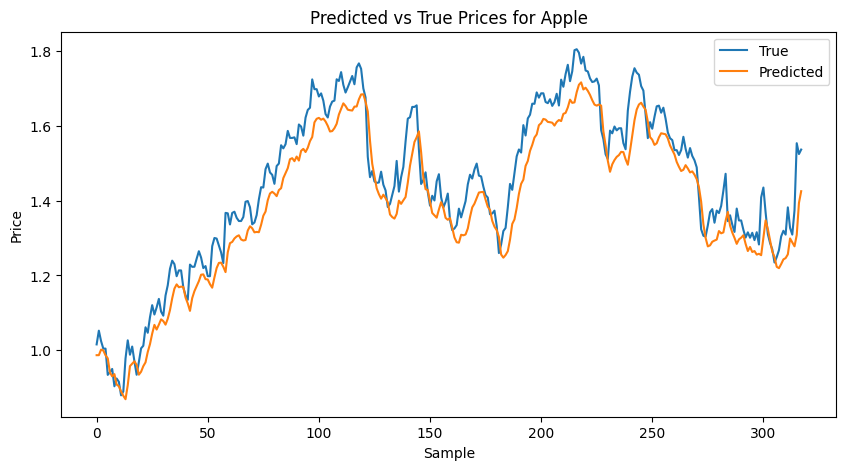

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Apple")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

/tmp/ipython-input-1446275713.py:429: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]


Price data shape: (2132, 10)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Judge grills Apple exec about whether company ...   
1  2024-05-08  Apple’s Unionized Maryland Store to Vote on Po...   
2  2024-05-08  Music streaming firms urge European Commission...   
3  2024-05-08     The 3 Best Metaverse Stocks to Buy in May 2024   
4  2024-05-08  Apple’s iPad event was an AI teaser for its fu...   

                                            mentions     label     score  
0  ['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...   Neutral  0.999480  
1  ['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...   Neutral  0.997899  
2  ['0R2V.IL', '639.F', '639.STU', '639.XETRA', '...   Neutral  0.968753  
3  ['AAPL.US', 'ELF.US', 'META.US', 'MSFT.US', 'N...  Positive  0.984462  
4  ['0QYP.IL', '0QZD.LSE', '0QZI.LSE', '0R1O.IL',...  Positive  0.641182  
Aggregating sentiment per company-day...
Sentiment df head:
            AAPL 

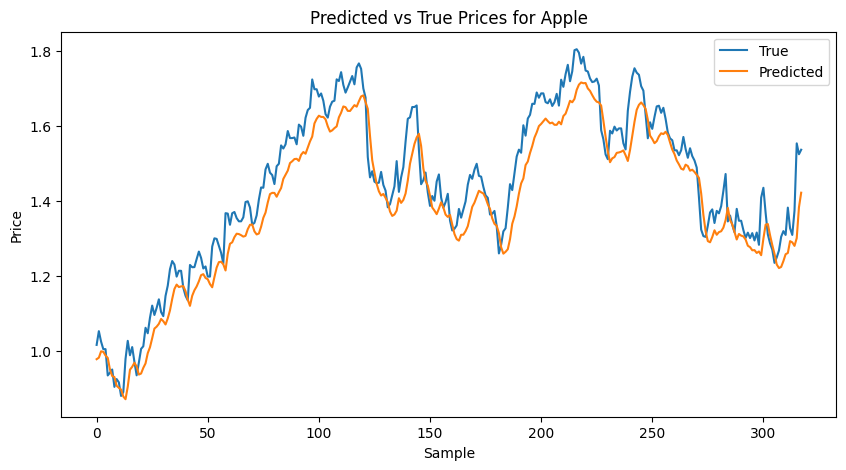

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Apple")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
sentiment_df.describe()

,AAPL,AMZN,GOOGL,TSLA,NFLX,MSFT,META,005930.KS,CMCSA,IT
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.0,167.000000,167.000000
mean,0.061581,0.150517,0.106305,0.032681,0.031575,0.163240,0.147810,0.0,-0.010704,-0.005983
std,0.197130,0.344081,0.386333,0.330868,0.288588,0.368959,0.382692,0.0,0.175786,0.077322
min,-0.571599,-0.999858,-0.999942,-0.999873,-0.999995,-0.998184,-0.999997,0.0,-0.996773,-0.999217
25%,-0.045797,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
50%,0.067122,0.000395,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
75%,0.170446,0.332892,0.182663,0.000000,0.000000,0.377964,0.333317,0.0,0.000000,0.000000
max,0.978029,0.999998,1.000000,0.999817,1.000000,0.999999,1.000000,0.0,0.999998,0.000000


In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (2132, 10)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Judge grills Apple exec about whether company ...   
1  2024-05-08  Apple’s Unionized Maryland Store to Vote on Po...   
2  2024-05-08  Music streaming firms urge European Commission...   
3  2024-05-08     The 3 Best Metaverse Stocks to Buy in May 2024   
4  2024-05-08  Apple’s iPad event was an AI teaser for its fu...   

                                            mentions     label     score  
0  ['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...   Neutral  0.999480  
1  ['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...   Neutral  0.997899  
2  ['0R2V.IL', '639.F', '639.STU', '639.XETRA', '...   Neutral  0.968753  
3  ['AAPL.US', 'ELF.US', 'META.US', 'MSFT.US', 'N...  Positive  0.984462  
4  ['0QYP.IL', '0QZD.LSE', '0QZI.LSE', '0R1O.IL',...  Positive  0.641182  
Aggregating sentiment per company-day...
Sentiment df head:
            AAPL 

### HSBC

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (1769, 10)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08              HSBC Holdings PLC's Dividend Analysis   
1  2024-05-06  Top Three UK Dividend Stocks To Watch In May 2024   
2  2024-05-04  Ping An votes against reappointment of HSBC CE...   
3  2024-05-04  HSBC Holdings First Quarter 2024 Earnings: Bea...   
4  2024-05-03  3 Foreign Bank Stocks Worth a Look in a Prospe...   

                                            mentions     label     score  
0  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...   Neutral  0.999954  
1  ['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...   Neutral  0.999904  
2  ['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...   Neutral  0.999888  
3  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...  Positive  1.000000  
4  ['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...   Neutral  0.973849  
Aggregating sentiment per company-day...
Sentiment df head:
            0005.

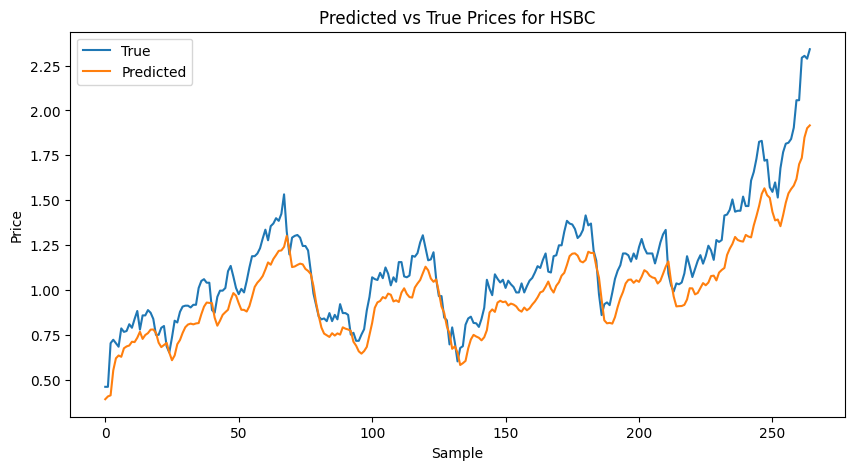

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for HSBC")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

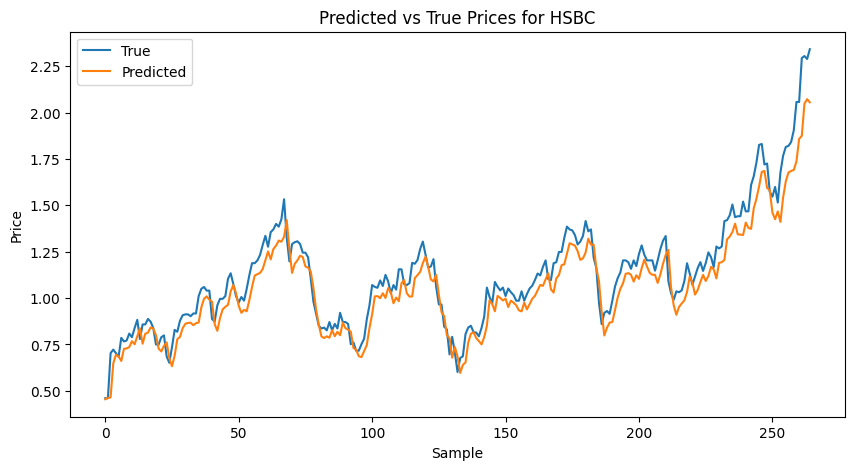

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for HSBC")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=16,
        epochs=15,
        device_str="cpu",
    )

Price data shape: (1769, 10)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08              HSBC Holdings PLC's Dividend Analysis   
1  2024-05-06  Top Three UK Dividend Stocks To Watch In May 2024   
2  2024-05-04  Ping An votes against reappointment of HSBC CE...   
3  2024-05-04  HSBC Holdings First Quarter 2024 Earnings: Bea...   
4  2024-05-03  3 Foreign Bank Stocks Worth a Look in a Prospe...   

                                            mentions     label     score  
0  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...   Neutral  0.999954  
1  ['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...   Neutral  0.999904  
2  ['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...   Neutral  0.999888  
3  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...  Positive  1.000000  
4  ['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...   Neutral  0.973849  
Aggregating sentiment per company-day...
Sentiment df head:
            0005.

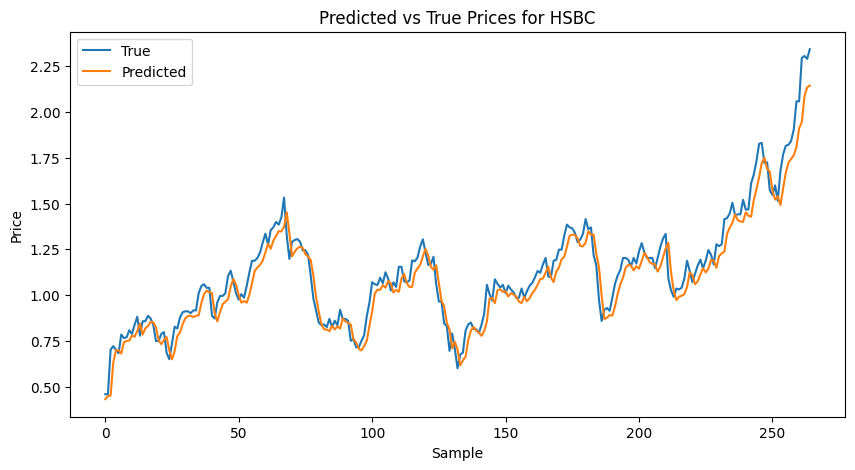

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for HSBC")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=24,
        co_window=5,
        batch_size=16,
        epochs=5,
        device_str="cpu",
    )

/tmp/ipython-input-1446275713.py:429: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]


Price data shape: (1769, 10)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08              HSBC Holdings PLC's Dividend Analysis   
1  2024-05-06  Top Three UK Dividend Stocks To Watch In May 2024   
2  2024-05-04  Ping An votes against reappointment of HSBC CE...   
3  2024-05-04  HSBC Holdings First Quarter 2024 Earnings: Bea...   
4  2024-05-03  3 Foreign Bank Stocks Worth a Look in a Prospe...   

                                            mentions     label     score  
0  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...   Neutral  0.999954  
1  ['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...   Neutral  0.999904  
2  ['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...   Neutral  0.999888  
3  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...  Positive  1.000000  
4  ['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...   Neutral  0.973849  
Aggregating sentiment per company-day...
Sentiment df head:
            0005.

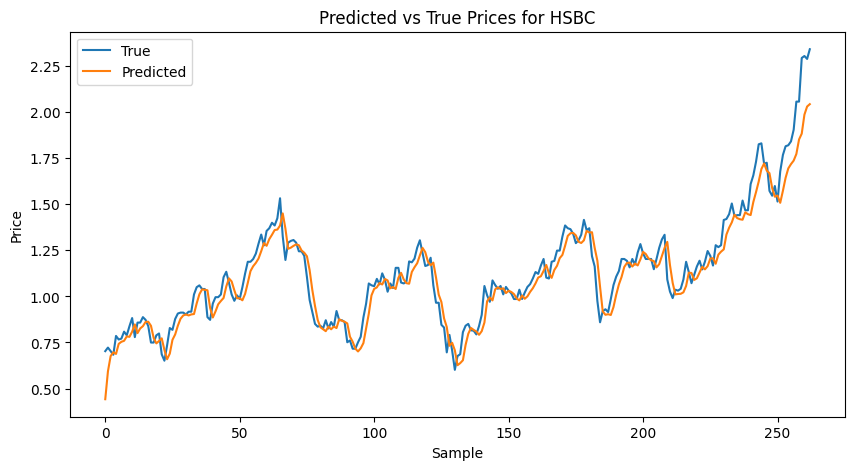

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for HSBC")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
sentiment_df.describe()

,0005.HK,JPM,2888.HK,MS,UBS,C,GS,NWG,AAPL,MSFT
count,1769.0,1769.000000,1769.0,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000,1769.000000
mean,0.0,0.001144,0.0,0.000365,0.002713,-0.001094,0.002388,0.001759,0.003264,-0.000565
std,0.0,0.098604,0.0,0.048934,0.100664,0.093968,0.101276,0.107547,0.063608,0.041175
min,0.0,-1.000000,0.0,-0.995134,-0.999995,-1.000000,-0.999823,-0.999836,-0.658666,-0.999983
25%,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.0,1.000000,0.0,0.999984,1.000000,1.000000,1.000000,1.000000,1.000000,0.999826


In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

/tmp/ipython-input-1446275713.py:429: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]


Price data shape: (1769, 10)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08              HSBC Holdings PLC's Dividend Analysis   
1  2024-05-06  Top Three UK Dividend Stocks To Watch In May 2024   
2  2024-05-04  Ping An votes against reappointment of HSBC CE...   
3  2024-05-04  HSBC Holdings First Quarter 2024 Earnings: Bea...   
4  2024-05-03  3 Foreign Bank Stocks Worth a Look in a Prospe...   

                                            mentions     label     score  
0  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...   Neutral  0.999954  
1  ['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...   Neutral  0.999904  
2  ['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...   Neutral  0.999888  
3  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...  Positive  1.000000  
4  ['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...   Neutral  0.973849  
Aggregating sentiment per company-day...
Sentiment df head:
            0005.

### Pepsi

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=20,
        device_str="cpu",
    )

Price data shape: (2145, 13)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  Positive  1.000000  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   Neutral  0.999939  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   Neutral  0.937144  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  Positive  1.000000  
4                               ['JNJ.US', 'PEP.US']  Positive  1.000000  
Aggregating sentiment per company-day...
Sentiment df head:
            PEP  

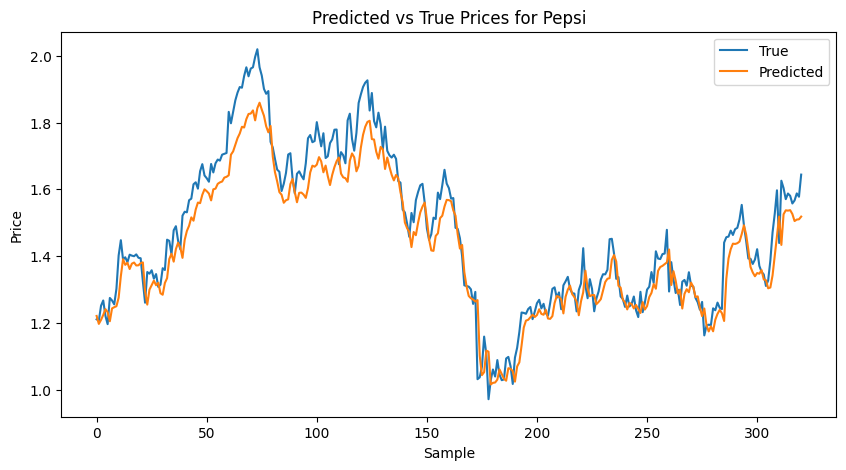

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Pepsi")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=16,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (2145, 13)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  Positive  1.000000  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   Neutral  0.999939  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   Neutral  0.937144  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  Positive  1.000000  
4                               ['JNJ.US', 'PEP.US']  Positive  1.000000  
Aggregating sentiment per company-day...
Sentiment df head:
            PEP  

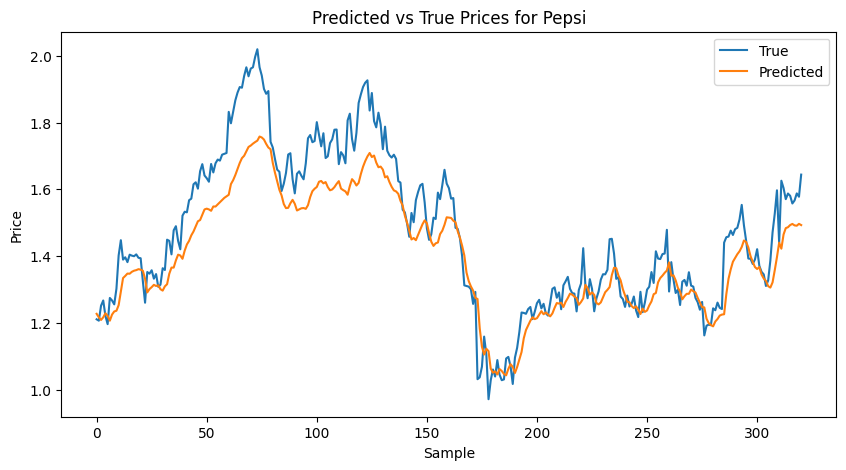

In [ ]:
# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Pepsi")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=16,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (2145, 13)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  Positive  1.000000  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   Neutral  0.999939  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   Neutral  0.937144  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  Positive  1.000000  
4                               ['JNJ.US', 'PEP.US']  Positive  1.000000  
Aggregating sentiment per company-day...
Sentiment df head:
            PEP  

### Toyota

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (2249, 13)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Toyota issues muted profit forecast following ...   
1  2024-05-08  Every household should be forced to have a sma...   
2  2024-05-08  Trending tickers: Apple, Reddit, JD Wetherspoo...   
3  2024-05-08  Toyota Motor Projects Drop in Fiscal-Year Prof...   
4  2024-05-08  Toyota racks up booming profit, vows to invest...   

                                            mentions     label     score  
0  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TMN.MX', '...  Negative  0.999979  
1  ['1BMW.MI', '2330.TW', '7203.TSE', '9984.TSE',...   Neutral  0.999996  
2  ['7203.TSE', 'ARM.US', 'TM.US', 'TMCO34.SA', '...   Neutral  0.999919  
3  ['6201.TSE', '7203.TSE', 'TAH.F', 'TM.US', 'TM...  Negative  0.999802  
4  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TOM.BE', '...  Positive  0.994673  
Aggregating sentiment per company-day...
Sentiment df head:
            7203.

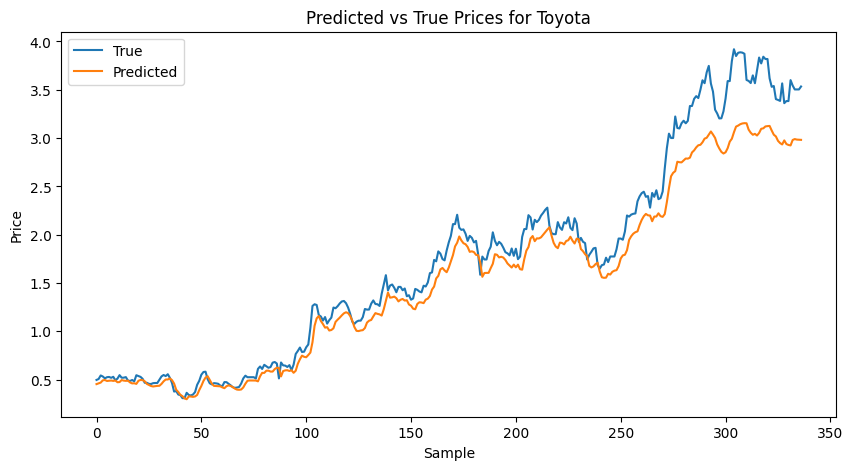

In [ ]:
# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Toyota")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (2249, 13)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Toyota issues muted profit forecast following ...   
1  2024-05-08  Every household should be forced to have a sma...   
2  2024-05-08  Trending tickers: Apple, Reddit, JD Wetherspoo...   
3  2024-05-08  Toyota Motor Projects Drop in Fiscal-Year Prof...   
4  2024-05-08  Toyota racks up booming profit, vows to invest...   

                                            mentions     label     score  
0  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TMN.MX', '...  Negative  0.999979  
1  ['1BMW.MI', '2330.TW', '7203.TSE', '9984.TSE',...   Neutral  0.999996  
2  ['7203.TSE', 'ARM.US', 'TM.US', 'TMCO34.SA', '...   Neutral  0.999919  
3  ['6201.TSE', '7203.TSE', 'TAH.F', 'TM.US', 'TM...  Negative  0.999802  
4  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TOM.BE', '...  Positive  0.994673  
Aggregating sentiment per company-day...
Sentiment df head:
            7203.

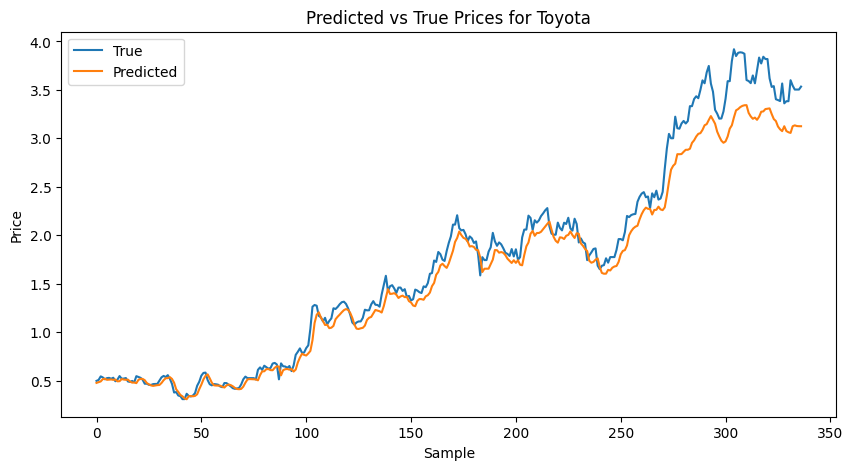

In [ ]:
# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Toyota")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        #tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (2249, 13)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Toyota issues muted profit forecast following ...   
1  2024-05-08  Every household should be forced to have a sma...   
2  2024-05-08  Trending tickers: Apple, Reddit, JD Wetherspoo...   
3  2024-05-08  Toyota Motor Projects Drop in Fiscal-Year Prof...   
4  2024-05-08  Toyota racks up booming profit, vows to invest...   

                                            mentions     label     score  
0  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TMN.MX', '...  Negative  0.999979  
1  ['1BMW.MI', '2330.TW', '7203.TSE', '9984.TSE',...   Neutral  0.999996  
2  ['7203.TSE', 'ARM.US', 'TM.US', 'TMCO34.SA', '...   Neutral  0.999919  
3  ['6201.TSE', '7203.TSE', 'TAH.F', 'TM.US', 'TM...  Negative  0.999802  
4  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TOM.BE', '...  Positive  0.994673  
Aggregating sentiment per company-day...
Sentiment df head:
            7203.

### Tencent

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (1778, 12)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Tencent, Alibaba Earnings Are Key to Longer Ch...   
1  2024-05-07  The 3 Most Undervalued Chinese Stocks to Buy i...   
2  2024-05-04  Stock Market Crash Alert: 3 Must-Buy Social Me...   
3  2024-05-03  3 Under-The-Radar Stocks That Could Be Worth O...   
4  2024-04-30  Alibaba Stock Analysis: Why BABA Is a China Be...   

                                            mentions     label     score  
0  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   Neutral  0.779458  
1  ['0700.HK', '9888.HK', 'B1C.F', 'B1C.STU', 'B1...  Positive  0.999979  
2  ['0700.HK', 'DJT.US', 'META.US', 'NNN1.BE', 'N...  Negative  0.972868  
3  ['0700.HK', '0YXG.LSE', '1YD.BE', '1YD.DU', '1...   Neutral  0.995232  
4  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   Neutral  0.999677  
Aggregating sentiment per company-day...
Sentiment df head:
            0700.

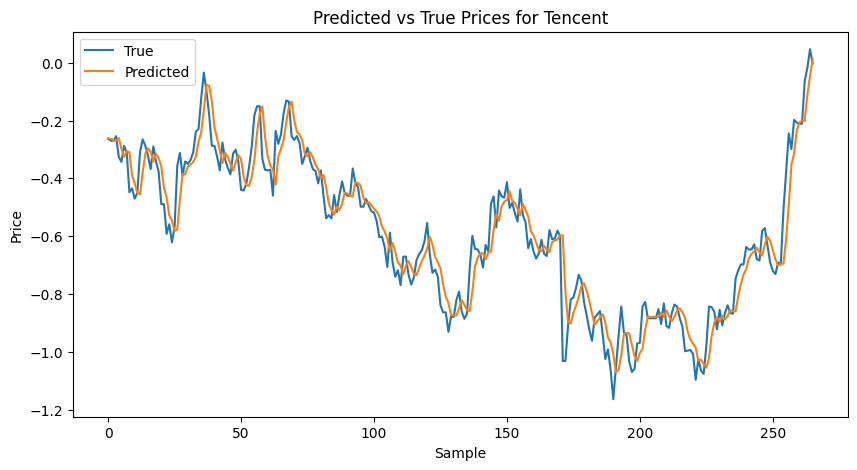

In [ ]:
# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Tencent")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

Price data shape: (1778, 12)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Tencent, Alibaba Earnings Are Key to Longer Ch...   
1  2024-05-07  The 3 Most Undervalued Chinese Stocks to Buy i...   
2  2024-05-04  Stock Market Crash Alert: 3 Must-Buy Social Me...   
3  2024-05-03  3 Under-The-Radar Stocks That Could Be Worth O...   
4  2024-04-30  Alibaba Stock Analysis: Why BABA Is a China Be...   

                                            mentions     label     score  
0  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   Neutral  0.779458  
1  ['0700.HK', '9888.HK', 'B1C.F', 'B1C.STU', 'B1...  Positive  0.999979  
2  ['0700.HK', 'DJT.US', 'META.US', 'NNN1.BE', 'N...  Negative  0.972868  
3  ['0700.HK', '0YXG.LSE', '1YD.BE', '1YD.DU', '1...   Neutral  0.995232  
4  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   Neutral  0.999677  
Aggregating sentiment per company-day...
Sentiment df head:
            0700.

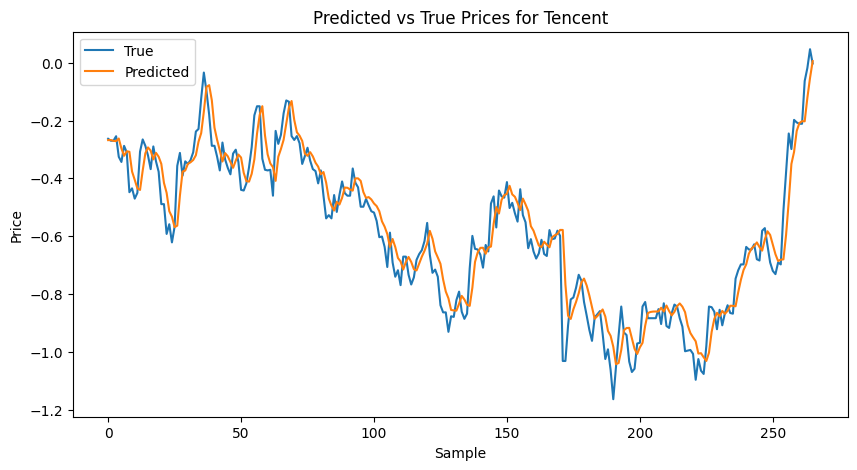

In [ ]:
# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Tencent")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ = full_news_demo(
        #tickers=["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"], #for Apple
        #tickers=["0005.HK","JPM","2888.HK","MS","UBS","C","GS","NWG","AAPL","MSFT"],   #for HSBC
        #tickers = ["PEP","KO", "WMT", "COST", "CL", "CVX", "PG", "JNJ", "AAPL", "MSFT", "AMZN", "TSLA", "IBM"], #for Pepsi
        #tickers = ["7203.T","7201.T", "7267.T", "7261.T", "F", "GM", "VOW3.DE", "BMW.DE", "TSLA", "005380.KS", "002594.SZ", "AAPL", "AMZN"],
        tickers = ["0700.HK", "NTES", "BABA", "JD", "BIDU", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "NVDA", "INTC"],
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=12,
        co_window=5,
        batch_size=8,
        epochs=5,
        device_str="cpu",
    )

/tmp/ipython-input-1446275713.py:429: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]


Price data shape: (1778, 12)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Tencent, Alibaba Earnings Are Key to Longer Ch...   
1  2024-05-07  The 3 Most Undervalued Chinese Stocks to Buy i...   
2  2024-05-04  Stock Market Crash Alert: 3 Must-Buy Social Me...   
3  2024-05-03  3 Under-The-Radar Stocks That Could Be Worth O...   
4  2024-04-30  Alibaba Stock Analysis: Why BABA Is a China Be...   

                                            mentions     label     score  
0  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   Neutral  0.779458  
1  ['0700.HK', '9888.HK', 'B1C.F', 'B1C.STU', 'B1...  Positive  0.999979  
2  ['0700.HK', 'DJT.US', 'META.US', 'NNN1.BE', 'N...  Negative  0.972868  
3  ['0700.HK', '0YXG.LSE', '1YD.BE', '1YD.DU', '1...   Neutral  0.995232  
4  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   Neutral  0.999677  
Aggregating sentiment per company-day...
Sentiment df head:
            0700.

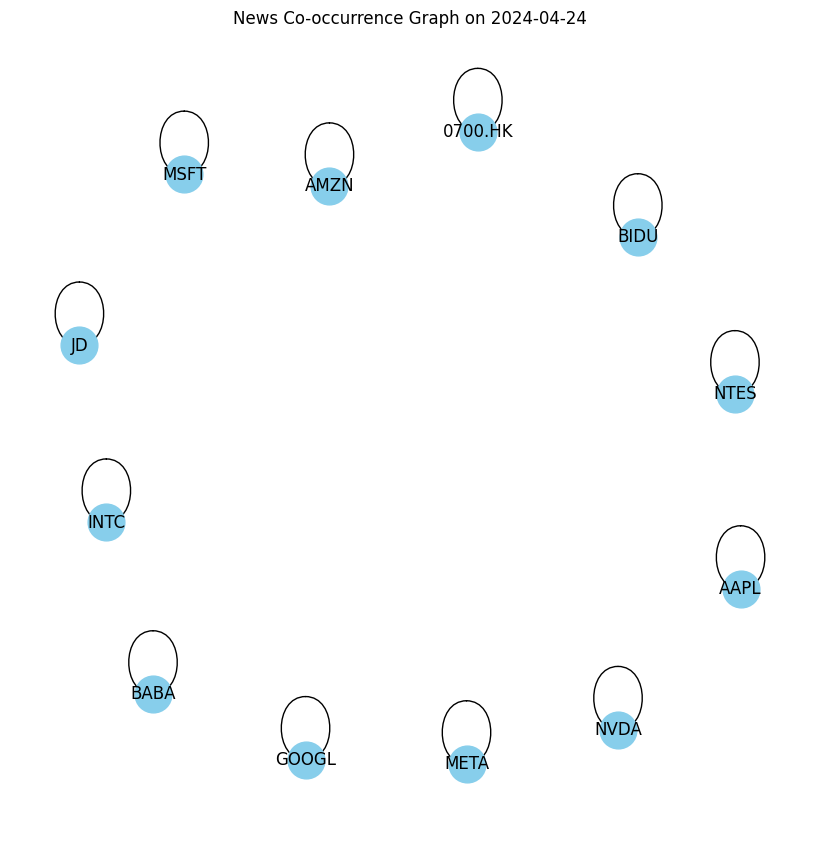

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Pick a target date
target_date = pd.to_datetime(price_df.index[-10]).date()  # last available date
tickers = list(price_df.columns)

# Get edges and weights from your function
edge_index, edge_weight = news_cooccurrence_graph_for_day(news_labeled, tickers, target_date, window=5)

# Build a NetworkX graph
G = nx.Graph()
for i, t in enumerate(tickers):
    G.add_node(i, label=t)

# Add edges with weights
for (src, dst), w in zip(edge_index.T, edge_weight):
    G.add_edge(src, dst, weight=w)

# Draw
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
labels = {i: tickers[i] for i in range(len(tickers))}
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw(G, pos, with_labels=True, labels=labels, width=weights, node_size=700, node_color='skyblue', font_size=12)
plt.title(f"News Co-occurrence Graph on {target_date}")
plt.show()

In [ ]:
sentiment_df['date'] = pd.to_datetime(sentiment_df.index)
sentiment_df.reset_index(drop=True, inplace=True)
sentiment_df.tail()

,0700.HK,NTES,BABA,JD,BIDU,MSFT,AAPL,GOOGL,AMZN,META,NVDA,INTC,date
1773,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-01
1774,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-02
1775,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-03
1776,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-06
1777,0.0,0.0,0.999979,0.0,0.999979,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-07


In [ ]:
sentiment_df.reset_index(drop=True, inplace=True)
sentiment_df.tail()

,0700.HK,NTES,BABA,JD,BIDU,MSFT,AAPL,GOOGL,AMZN,META,NVDA,INTC,date
1773,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-01
1774,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-02
1775,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-03
1776,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-06
1777,0.0,0.0,0.999979,0.0,0.999979,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-05-07


In [ ]:
sentiment_df.rename(columns={'AAPL': 'sentiment'}, inplace=True)
#sentiment_df.rename(columns={'0005.HK': 'sentiment'}, inplace=True)
#sentiment_df.rename(columns={'PEP': 'sentiment'}, inplace=True)
#sentiment_df.rename(columns={'0700.HK': 'sentiment'}, inplace=True)
#sentiment_df.rename(columns={'7203.T': 'sentiment'}, inplace=True)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
sentiment_df.describe()

,0700.HK,NTES,BABA,JD,BIDU,MSFT,AAPL,GOOGL,AMZN,META,NVDA,INTC,date
count,1778.0,1778.000000,1778.000000,1778.000000,1778.000000,1778.000000,1778.000000,1778.000000,1778.000000,1778.000000,1778.000000,1778.000000,1778
mean,0.0,0.004019,-0.006382,0.005227,0.002081,0.002812,-0.000992,-0.000997,-0.001441,0.001124,0.002723,0.002249,2020-11-25 04:26:27.401574656
min,0.0,-1.000000,-1.000000,-1.000000,-0.999999,-0.999987,-0.999998,-0.999981,-0.999997,-0.999987,0.000000,-0.999906,2017-06-15 00:00:00
25%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-03-07 06:00:00
50%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2020-11-24 12:00:00
75%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-08-15 18:00:00
max,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2024-05-07 00:00:00
std,0.0,0.121393,0.226879,0.140766,0.177261,0.105713,0.133541,0.064393,0.126825,0.074770,0.049258,0.058042,NaN


In [ ]:
sentiment_df.columns

Index(['AAPL', 'AMZN', 'GOOGL', 'TSLA', 'NFLX', 'MSFT', 'META', '005930.KS',
       'CMCSA', 'IT', 'date'],
      dtype='object')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =======================================
# 1. Define Models
# =======================================
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.gru(x)            # out: (batch, seq_len, hidden_dim)
        out = self.fc(out[:, -1, :])    # take last time-step
        return out


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_dim)
        out = self.fc(out[:, -1, :])    # take last time-step
        return out


class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        # Use batch_first=True so we can feed (batch, seq_len, d_model) directly
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.input_fc(x)            # (batch, seq_len, hidden_dim)
        x = self.transformer(x)         # (batch, seq_len, hidden_dim)
        x = self.fc(x[:, -1, :])        # take last time-step
        return x


class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # aggregate neighbors
        out = self.fc(out)
        return torch.relu(out)


class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)


# =======================================
# 2. Data Preparation (Fixed)
# =======================================
data = yf.Ticker('AAPL')
data = data.history(start=apple_data["date"].min(), end=apple_data["date"].max())
data['date'] = pd.to_datetime(data.index)
data = data.reset_index(drop=True)
data = data[['date', 'Close']]

# Ensure both timezone-naive
data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
#sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.tz_localize(None)

# Merge with sentiment data
merged = pd.merge(data, sentiment_df, on="date", how="left").fillna(0)


# Compute daily return and rolling volatility (5-day)
#merged["return"] = merged["Close"].pct_change()
merged["volatility"] = merged["Close"].rolling(window=5).std()


# Drop NaNs after computing return and volatility
merged = merged.dropna().reset_index(drop=True)
print(merged)


# Select final features
features = merged[["Close","volatility",'AAPL', 'AMZN', 'GOOGL', 'TSLA', 'NFLX', 'MSFT', 'META', '005930.KS',
       'CMCSA', 'IT']]
target = merged["Close"].shift(-1)

# Drop last row (target NaN)
merged = merged.iloc[:-1]
features = features.iloc[:-1]
target = target.dropna()
features = features.dropna()

# Normalize features
#features = (features - features.min()) / ((features.max() - features.min())+0.00001)

# Double-check for NaNs before training
assert not features.isna().any().any(), "Features contain NaN!"
assert not target.isna().any(), "Target contains NaN!"

# Convert to numpy
values = features.values.astype(np.float32)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Scale features
values = scaler_x.fit_transform(features).astype(np.float32)

# Scale targets if using price changes
y = target.values.astype(np.float32).reshape(-1, 1)
y = scaler_y.fit_transform(y)

# =======================================
# 3. Create Sliding Window Dataset
# =======================================
seq_len = 10
X = []
for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])

X = np.array(X)
y = y[seq_len:]

split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = features.shape[1]  # should be 1 since you're only using Close price


# =======================================
# 4. Train & Evaluate
# =======================================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1)
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=50)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")


           date       Close      AAPL      AMZN     GOOGL  TSLA  NFLX  \
0    2016-02-25   21.934761  0.000000  0.000000  0.000000   0.0   0.0   
1    2016-02-26   21.968760  0.000000  0.000000  0.000000   0.0   0.0   
2    2016-02-29   21.918884  0.000000  0.000000  0.000000   0.0   0.0   
3    2016-03-01   22.789381  0.000000  0.000000  0.000000   0.0   0.0   
4    2016-03-02   22.839258  0.000000  0.000000  0.000000   0.0   0.0   
...         ...         ...       ...       ...       ...   ...   ...   
2059 2024-05-01  167.930099  0.124456  0.000000  0.000000   0.0   0.0   
2060 2024-05-02  171.629959  0.426675  0.000000  0.000000   0.0   0.0   
2061 2024-05-03  181.896179  0.263737 -0.999858 -0.999858   0.0   0.0   
2062 2024-05-06  180.239685 -0.022472  0.000000  0.000000   0.0   0.0   
2063 2024-05-07  180.924118  0.147370 -0.272541  0.000000   0.0   0.0   

          MSFT     META  005930.KS  CMCSA   IT  volatility  
0     0.000000  0.00000        0.0    0.0  0.0    0.197480  
1

In [ ]:
merged.describe()

,date,Close,sentiment,rolling_mean,volatility
count,2066,2066.000000,2066.0,2066.000000,2066.000000
mean,2020-03-27 17:33:09.932236288,93.023565,0.0,92.872555,1.398839
min,2016-02-22 00:00:00,20.604082,0.0,20.963522,0.025594
25%,2018-03-09 18:00:00,40.231371,0.0,40.184042,0.403201
50%,2020-03-28 12:00:00,74.575226,0.0,74.094252,1.021501
75%,2022-04-13 18:00:00,146.560265,0.0,146.299242,2.022177
max,2024-05-06 00:00:00,196.256577,0.0,195.448209,8.448702
std,NaN,57.167885,0.0,57.124484,1.276594


### HSBC

In [ ]:
sentiment_df.columns.to_list().remove("date")

['0005.HK',
 'JPM',
 '2888.HK',
 'MS',
 'UBS',
 'C',
 'GS',
 'NWG',
 'AAPL',
 'MSFT',
 'date']

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =======================================
# 1. Define Models
# =======================================
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.gru(x)            # out: (batch, seq_len, hidden_dim)
        out = self.fc(out[:, -1, :])    # take last time-step
        return out


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_dim)
        out = self.fc(out[:, -1, :])    # take last time-step
        return out


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2, max_len=500):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """
        x: shape (batch_size, seq_len, input_dim)
        """
        x = self.input_fc(x)              # (batch_size, seq_len, hidden_dim)
        x = self.pos_encoder(x)           # add positional encoding
        x = self.transformer(x)           # (batch_size, seq_len, hidden_dim)
        x = self.fc(x[:, -1, :])          # take last time step for scalar prediction
        return x


class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # aggregate neighbors
        out = self.fc(out)
        return torch.relu(out)


class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)


# =======================================
# 2. Data Preparation (Fixed)
# =======================================
data = yf.Ticker('0005.HK')
data = data.history(start=apple_data["date"].min(), end=apple_data["date"].max())
data['date'] = pd.to_datetime(data.index)
data = data.reset_index(drop=True)
data = data[['date', 'Close']]

# Ensure both timezone-naive
data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
#sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.tz_localize(None)

# Merge with sentiment data
merged = pd.merge(data, sentiment_df, on="date", how="left").fillna(0)



# Compute daily return and rolling volatility (5-day)
#merged["return"] = merged["Close"].pct_change()
merged["volatility"] = merged["Close"].rolling(window=5).std()


# Drop NaNs after computing return and volatility
merged = merged.dropna().reset_index(drop=True)
print(merged)


# Select final features
features = merged[["Close","volatility",'0005.HK',
                  'JPM',
                  '2888.HK',
                  'MS',
                  'UBS',
                  'C',
                  'GS',
                  'NWG',
                  'AAPL',
                  'MSFT']]
target = merged["Close"].shift(-1)

# Drop last row (target NaN)
merged = merged.iloc[:-1]
features = features.iloc[:-1]
target = target.dropna()
features = features.dropna()

# Normalize features
#features = (features - features.min()) / ((features.max() - features.min())+0.00001)

# Double-check for NaNs before training
assert not features.isna().any().any(), "Features contain NaN!"
assert not target.isna().any(), "Target contains NaN!"

# Convert to numpy
values = features.values.astype(np.float32)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Scale features
values = scaler_x.fit_transform(features).astype(np.float32)

# Scale targets if using price changes
y = target.values.astype(np.float32).reshape(-1, 1)
y = scaler_y.fit_transform(y)

# =======================================
# 3. Create Sliding Window Dataset
# =======================================
seq_len = 10
X = []
for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])

X = np.array(X)
y = y[seq_len:]

split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = features.shape[1]  # should be 1 since you're only using Close price


# =======================================
# 4. Train & Evaluate
# =======================================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1)
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=50)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")

           date      Close  0005.HK  JPM  2888.HK   MS  UBS    C   GS  NWG  \
0    2017-07-04  47.487812      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
1    2017-07-05  47.682163      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
2    2017-07-06  47.520218      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
3    2017-07-07  47.390636      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
4    2017-07-10  48.330025      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
...         ...        ...      ...  ...      ...  ...  ...  ...  ...  ...   
1681 2024-04-30  60.242416      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
1682 2024-05-02  62.265484      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
1683 2024-05-03  62.355396      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
1684 2024-05-06  62.220512      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   
1685 2024-05-07  62.670086      0.0  0.0      0.0  0.0  0.0  0.0  0.0  0.0   

      AAPL  MSFT  volatility  
0      0.0   0.0    1.346425  
1

### Pepsi

In [ ]:
sentiment_df.columns

Index(['PEP', 'KO', 'WMT', 'COST', 'CL', 'CVX', 'PG', 'JNJ', 'AAPL', 'MSFT',
       'AMZN', 'TSLA', 'IBM', 'date'],
      dtype='object')

In [ ]:

# =======================================
# 2. Data Preparation (Fixed)
# =======================================
data = yf.Ticker('PEP')
data = data.history(start=apple_data["date"].min(), end=apple_data["date"].max())
data['date'] = pd.to_datetime(data.index)
data = data.reset_index(drop=True)
data = data[['date', 'Close']]

# Ensure both timezone-naive
data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
#sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.tz_localize(None)

# Merge with sentiment data
merged = pd.merge(data, sentiment_df, on="date", how="left").fillna(0)


# Compute daily return and rolling volatility (5-day)
#merged["return"] = merged["Close"].pct_change()
merged["volatility"] = merged["Close"].rolling(window=5).std()


# Drop NaNs after computing return and volatility
merged = merged.dropna().reset_index(drop=True)
print(merged)


# Select final features
features = merged[["Close","volatility",'PEP', 'KO', 'WMT', 'COST', 'CL', 'CVX', 'PG', 'JNJ', 'AAPL', 'MSFT',
       'AMZN', 'TSLA', 'IBM']]
target = merged["Close"].shift(-1)

# Drop last row (target NaN)
merged = merged.iloc[:-1]
features = features.iloc[:-1]
target = target.dropna()
features = features.dropna()

# Normalize features
#features = (features - features.min()) / ((features.max() - features.min())+0.00001)

# Double-check for NaNs before training
assert not features.isna().any().any(), "Features contain NaN!"
assert not target.isna().any(), "Target contains NaN!"

# Convert to numpy
values = features.values.astype(np.float32)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Scale features
values = scaler_x.fit_transform(features).astype(np.float32)

# Scale targets if using price changes
y = target.values.astype(np.float32).reshape(-1, 1)
y = scaler_y.fit_transform(y)

# =======================================
# 3. Create Sliding Window Dataset
# =======================================
seq_len = 10
X = []
for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])

X = np.array(X)
y = y[seq_len:]

split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = features.shape[1]  # should be 1 since you're only using Close price


# =======================================
# 4. Train & Evaluate
# =======================================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1)
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=50)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")

           date       Close       PEP   KO  WMT  COST   CL  CVX   PG  JNJ  \
0    2015-11-03   74.862839  0.000000  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
1    2015-11-04   74.640297  0.000000  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
2    2015-11-05   74.632874  0.000000  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
3    2015-11-06   73.972679  0.000000  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
4    2015-11-09   73.349548  0.000000  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
...         ...         ...       ...  ...  ...   ...  ...  ...  ...  ...   
2136 2024-05-01  166.047501  0.000000  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
2137 2024-05-02  166.331909 -0.122370  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
2138 2024-05-03  166.995514  0.000000  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
2139 2024-05-06  166.682678 -0.427434  0.0  0.0   0.0  0.0  0.0  0.0  0.0   
2140 2024-05-07  168.768356  0.000000  0.0  0.0   0.0  0.0  0.0  0.0  0.0   

      AAPL  MSFT      AMZN  TSLA  IBM  volatility  
0      0.0   0.0  0.000

### Toyota

In [ ]:
sentiment_df.columns

Index(['7203.T', '7201.T', '7267.T', '7261.T', 'F', 'GM', 'VOW3.DE', 'BMW.DE',
       'TSLA', '005380.KS', '002594.SZ', 'AAPL', 'AMZN', 'date'],
      dtype='object')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =======================================
# 1. Define Models
# =======================================
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.gru(x)            # out: (batch, seq_len, hidden_dim)
        out = self.fc(out[:, -1, :])    # take last time-step
        return out


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_dim)
        out = self.fc(out[:, -1, :])    # take last time-step
        return out


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2, max_len=500):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """
        x: shape (batch_size, seq_len, input_dim)
        """
        x = self.input_fc(x)              # (batch_size, seq_len, hidden_dim)
        x = self.pos_encoder(x)           # add positional encoding
        x = self.transformer(x)           # (batch_size, seq_len, hidden_dim)
        x = self.fc(x[:, -1, :])          # take last time step for scalar prediction
        return x


class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # aggregate neighbors
        out = self.fc(out)
        return torch.relu(out)


class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)

# =======================================
# 2. Data Preparation (Fixed)
# =======================================
data = yf.Ticker('7203.T')
data = data.history(start=apple_data["date"].min(), end=apple_data["date"].max())
data['date'] = pd.to_datetime(data.index)
data = data.reset_index(drop=True)
data = data[['date', 'Close']]

# Ensure both timezone-naive
data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
#sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.tz_localize(None)

# Merge with sentiment data
merged = pd.merge(data, sentiment_df, on="date", how="left").fillna(0)


# Compute daily return and rolling volatility (5-day)
#merged["return"] = merged["Close"].pct_change()
merged["volatility"] = merged["Close"].rolling(window=5).std()


# Drop NaNs after computing return and volatility
merged = merged.dropna().reset_index(drop=True)
print(merged)


# Select final features
features = merged[["Close","volatility",'7203.T', '7201.T', '7267.T', '7261.T', 'F', 'GM', 'VOW3.DE', 'BMW.DE',
       'TSLA', '005380.KS', '002594.SZ', 'AAPL', 'AMZN']]
target = merged["Close"].shift(-1)

# Drop last row (target NaN)
merged = merged.iloc[:-1]
features = features.iloc[:-1]
target = target.dropna()
features = features.dropna()

# Normalize features
#features = (features - features.min()) / ((features.max() - features.min())+0.00001)

# Double-check for NaNs before training
assert not features.isna().any().any(), "Features contain NaN!"
assert not target.isna().any(), "Target contains NaN!"

# Convert to numpy
values = features.values.astype(np.float32)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Scale features
values = scaler_x.fit_transform(features).astype(np.float32)

# Scale targets if using price changes
y = target.values.astype(np.float32).reshape(-1, 1)
y = scaler_y.fit_transform(y)

# =======================================
# 3. Create Sliding Window Dataset
# =======================================
seq_len = 10
X = []
for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])

X = np.array(X)
y = y[seq_len:]

split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = features.shape[1]  # should be 1 since you're only using Close price


# =======================================
# 4. Train & Evaluate
# =======================================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1)
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=50)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")

           date        Close  7203.T  7201.T  7267.T  7261.T         F  \
0    2015-09-28  1039.041626     0.0     0.0     0.0     0.0  0.000000   
1    2015-09-29   990.398621     0.0     0.0     0.0     0.0  0.000000   
2    2015-09-30  1027.543945     0.0     0.0     0.0     0.0  0.000000   
3    2015-10-01  1054.076416     0.0     0.0     0.0     0.0  0.000000   
4    2015-10-02  1069.701416     0.0     0.0     0.0     0.0  0.000000   
...         ...          ...     ...     ...     ...     ...       ...   
2118 2024-04-26  3345.884766     0.0     0.0     0.0     0.0  0.000000   
2119 2024-04-30  3467.900146     0.0     0.0     0.0     0.0  0.000000   
2120 2024-05-01  3436.442871     0.0     0.0     0.0     0.0  0.000000   
2121 2024-05-02  3413.564941     0.0     0.0     0.0     0.0  0.000000   
2122 2024-05-07  3430.723633     0.0     0.0     0.0     0.0  0.332697   

            GM  VOW3.DE  BMW.DE      TSLA  005380.KS  002594.SZ      AAPL  \
0     0.000000      0.0     0.0  0

### Tencent

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
sentiment_df.columns

Index(['0700.HK', 'NTES', 'BABA', 'JD', 'BIDU', 'MSFT', 'AAPL', 'GOOGL',
       'AMZN', 'META', 'NVDA', 'INTC', 'date'],
      dtype='object')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =======================================
# 1. Define Models
# =======================================
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.gru(x)            # out: (batch, seq_len, hidden_dim)
        out = self.fc(out[:, -1, :])    # take last time-step
        return out


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)           # out: (batch, seq_len, hidden_dim)
        out = self.fc(out[:, -1, :])    # take last time-step
        return out


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2, max_len=500):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """
        x: shape (batch_size, seq_len, input_dim)
        """
        x = self.input_fc(x)              # (batch_size, seq_len, hidden_dim)
        x = self.pos_encoder(x)           # add positional encoding
        x = self.transformer(x)           # (batch_size, seq_len, hidden_dim)
        x = self.fc(x[:, -1, :])          # take last time step for scalar prediction
        return x


class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # aggregate neighbors
        out = self.fc(out)
        return torch.relu(out)


class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)



# =======================================
# 2. Data Preparation (Fixed)
# =======================================
data = yf.Ticker('0700.HK')
data = data.history(start=apple_data["date"].min(), end=apple_data["date"].max())
data['date'] = pd.to_datetime(data.index)
data = data.reset_index(drop=True)
data = data[['date', 'Close']]

# Ensure both timezone-naive
data['date'] = pd.to_datetime(data['date']).dt.tz_localize(None)
#sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.tz_localize(None)

# Merge with sentiment data
merged = pd.merge(data, sentiment_df, on="date", how="left").fillna(0)


# Compute daily return and rolling volatility (5-day)
#merged["return"] = merged["Close"].pct_change()
merged["volatility"] = merged["Close"].rolling(window=5).std()


# Drop NaNs after computing return and volatility
merged = merged.dropna().reset_index(drop=True)
print(merged)


# Select final features
features = merged[["Close","volatility",'0700.HK', 'NTES', 'BABA', 'JD', 'BIDU', 'MSFT', 'AAPL', 'GOOGL',
       'AMZN', 'META', 'NVDA', 'INTC']]
target = merged["Close"].shift(-1)

# Drop last row (target NaN)
merged = merged.iloc[:-1]
features = features.iloc[:-1]
target = target.dropna()
features = features.dropna()

# Normalize features
#features = (features - features.min()) / ((features.max() - features.min())+0.00001)

# Double-check for NaNs before training
assert not features.isna().any().any(), "Features contain NaN!"
assert not target.isna().any(), "Target contains NaN!"

# Convert to numpy
values = features.values.astype(np.float32)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Scale features
values = scaler_x.fit_transform(features).astype(np.float32)

# Scale targets if using price changes
y = target.values.astype(np.float32).reshape(-1, 1)
y = scaler_y.fit_transform(y)

# =======================================
# 3. Create Sliding Window Dataset
# =======================================
seq_len = 10
X = []
for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])

X = np.array(X)
y = y[seq_len:]

split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = features.shape[1]  # should be 1 since you're only using Close price


# =======================================
# 4. Train & Evaluate
# =======================================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1)
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=50)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")

           date       Close  0700.HK  NTES      BABA   JD      BIDU  MSFT  \
0    2017-06-21  247.141998      0.0   0.0  0.000000  0.0  0.000000   0.0   
1    2017-06-22  249.266449      0.0   0.0  0.000000  0.0  0.000000   0.0   
2    2017-06-23  248.027191      0.0   0.0  0.000000  0.0  0.000000   0.0   
3    2017-06-26  251.390839      0.0   0.0  0.000000  0.0  0.000000   0.0   
4    2017-06-27  254.931580      0.0   0.0  0.000000  0.0  0.000000   0.0   
...         ...         ...      ...   ...       ...  ...       ...   ...   
1690 2024-04-30  341.247620      0.0   0.0  0.000000  0.0  0.000000   0.0   
1691 2024-05-02  354.221313      0.0   0.0  0.000000  0.0  0.000000   0.0   
1692 2024-05-03  358.152740      0.0   0.0  0.000000  0.0  0.000000   0.0   
1693 2024-05-06  363.853333      0.0   0.0  0.000000  0.0  0.000000   0.0   
1694 2024-05-07  359.528748      0.0   0.0  0.999979  0.0  0.999979   0.0   

      AAPL  GOOGL  AMZN  META  NVDA  INTC  volatility  
0      0.0    0.0  

In [ ]:
# =============================
# 1. Imports
# =============================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import yfinance as yf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================
# 2. Baseline Models
# =============================

# ----- GRU -----
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- LSTM -----
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- Transformer -----
class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x


# ----- GCN (Spatial-only) -----
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # Batched matrix multiplication
        out = self.fc(out)
        return torch.relu(out)

class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)


# =============================
# 3. Training & Evaluation
# =============================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


# =======================================
# 4. Download Apple stock data
# =======================================
ticker = "AAPL"
#ticker = "0005.HK"
#ticker = "PEP"
#ticker = "7203.T"
#ticker = "0700.HK"
data = yf.download(ticker, start=apple_data['date'].min(), end=apple_data['date'].max())
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

# Normalize features
data = (data - data.min()) / (data.max() - data.min())
values = data.values.astype(np.float32)

# =======================================
# 5. Create sliding window dataset
# =======================================
seq_len = 10
X, y = [], []

for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])              # past 10 days
    y.append(values[i+seq_len][3])             # next day's Close price

X = np.array(X)
y = np.array(y).reshape(-1, 1)

print(f"Data shape -> X: {X.shape}, y: {y.shape}")

# Split into train/test
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Dataloader
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = 5

# =======================================
# 6. Train & Test Each Model
# =======================================
models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1),
    "GCN": GCNModel(num_nodes=seq_len, in_features=num_features, hidden_dim=64, out_features=1),
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=30)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")


[*********************100%***********************]  1 of 1 completed


Data shape -> X: (153, 10, 5), y: (153, 1)

===== Training GRU =====
Epoch [1/30], Loss: 0.2480
Epoch [2/30], Loss: 0.0457
Epoch [3/30], Loss: 0.0336
Epoch [4/30], Loss: 0.0262
Epoch [5/30], Loss: 0.0219
Epoch [6/30], Loss: 0.0174
Epoch [7/30], Loss: 0.0156
Epoch [8/30], Loss: 0.0128
Epoch [9/30], Loss: 0.0128
Epoch [10/30], Loss: 0.0110
Epoch [11/30], Loss: 0.0120
Epoch [12/30], Loss: 0.0127
Epoch [13/30], Loss: 0.0138
Epoch [14/30], Loss: 0.0097
Epoch [15/30], Loss: 0.0118
Epoch [16/30], Loss: 0.0099
Epoch [17/30], Loss: 0.0095
Epoch [18/30], Loss: 0.0085
Epoch [19/30], Loss: 0.0081
Epoch [20/30], Loss: 0.0079
Epoch [21/30], Loss: 0.0089
Epoch [22/30], Loss: 0.0085
Epoch [23/30], Loss: 0.0079
Epoch [24/30], Loss: 0.0072
Epoch [25/30], Loss: 0.0079
Epoch [26/30], Loss: 0.0071
Epoch [27/30], Loss: 0.0066
Epoch [28/30], Loss: 0.0066
Epoch [29/30], Loss: 0.0066
Epoch [30/30], Loss: 0.0069
GRU Test MSE: 0.012184, MAE: 0.085920

===== Training LSTM =====
Epoch [1/30], Loss: 0.2330
Epoch [2

In [ ]:
# =============================
# 1. Imports
# =============================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import yfinance as yf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================
# 2. Baseline Models
# =============================

# ----- GRU -----
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- LSTM -----
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- Transformer -----
class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x


# ----- GCN (Spatial-only) -----
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # Batched matrix multiplication
        out = self.fc(out)
        return torch.relu(out)

class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)


# =============================
# 3. Training & Evaluation
# =============================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


# =======================================
# 4. Download Apple stock data
# =======================================
#ticker = "AAPL"
ticker = "0005.HK"
#ticker = "PEP"
#ticker = "7203.T"
#ticker = "0700.HK"
data = yf.download(ticker, start=apple_data['date'].min(), end=apple_data['date'].max())
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

# Normalize features
data = (data - data.min()) / (data.max() - data.min())
values = data.values.astype(np.float32)

# =======================================
# 5. Create sliding window dataset
# =======================================
seq_len = 10
X, y = [], []

for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])              # past 10 days
    y.append(values[i+seq_len][3])             # next day's Close price

X = np.array(X)
y = np.array(y).reshape(-1, 1)

print(f"Data shape -> X: {X.shape}, y: {y.shape}")

# Split into train/test
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Dataloader
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = 5

# =======================================
# 6. Train & Test Each Model
# =======================================
models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1),
    "GCN": GCNModel(num_nodes=seq_len, in_features=num_features, hidden_dim=64, out_features=1),
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=30)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")


[*********************100%***********************]  1 of 1 completed


Data shape -> X: (2091, 10, 5), y: (2091, 1)

===== Training GRU =====
Epoch [1/30], Loss: 0.0151
Epoch [2/30], Loss: 0.0009
Epoch [3/30], Loss: 0.0008
Epoch [4/30], Loss: 0.0008
Epoch [5/30], Loss: 0.0007
Epoch [6/30], Loss: 0.0007
Epoch [7/30], Loss: 0.0007
Epoch [8/30], Loss: 0.0006
Epoch [9/30], Loss: 0.0006
Epoch [10/30], Loss: 0.0006
Epoch [11/30], Loss: 0.0006
Epoch [12/30], Loss: 0.0006
Epoch [13/30], Loss: 0.0005
Epoch [14/30], Loss: 0.0005
Epoch [15/30], Loss: 0.0004
Epoch [16/30], Loss: 0.0005
Epoch [17/30], Loss: 0.0005
Epoch [18/30], Loss: 0.0004
Epoch [19/30], Loss: 0.0004
Epoch [20/30], Loss: 0.0004
Epoch [21/30], Loss: 0.0005
Epoch [22/30], Loss: 0.0004
Epoch [23/30], Loss: 0.0004
Epoch [24/30], Loss: 0.0004
Epoch [25/30], Loss: 0.0004
Epoch [26/30], Loss: 0.0004
Epoch [27/30], Loss: 0.0004
Epoch [28/30], Loss: 0.0003
Epoch [29/30], Loss: 0.0004
Epoch [30/30], Loss: 0.0004
GRU Test MSE: 0.000431, MAE: 0.015283

===== Training LSTM =====
Epoch [1/30], Loss: 0.0277
Epoch 

In [ ]:
# =============================
# 2. Baseline Models
# =============================

# ----- GRU -----
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- LSTM -----
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- Transformer -----
class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x


# ----- GCN (Spatial-only) -----
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # Batched matrix multiplication
        out = self.fc(out)
        return torch.relu(out)

class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)


# =============================
# 3. Training & Evaluation
# =============================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


# =======================================
# 4. Download Apple stock data
# =======================================
#ticker = "AAPL"
#ticker = "0005.HK"
ticker = "PEP"
#ticker = "7203.T"
#ticker = "0700.HK"
data = yf.download(ticker, start=apple_data['date'].min(), end=apple_data['date'].max())
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

# Normalize features
data = (data - data.min()) / (data.max() - data.min())
values = data.values.astype(np.float32)

# =======================================
# 5. Create sliding window dataset
# =======================================
seq_len = 10
X, y = [], []

for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])              # past 10 days
    y.append(values[i+seq_len][3])             # next day's Close price

X = np.array(X)
y = np.array(y).reshape(-1, 1)

print(f"Data shape -> X: {X.shape}, y: {y.shape}")

# Split into train/test
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Dataloader
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = 5

# =======================================
# 6. Train & Test Each Model
# =======================================
models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1),
    "GCN": GCNModel(num_nodes=seq_len, in_features=num_features, hidden_dim=64, out_features=1),
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=30)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")

[*********************100%***********************]  1 of 1 completed


Data shape -> X: (2135, 10, 5), y: (2135, 1)

===== Training GRU =====
Epoch [1/30], Loss: 0.0104
Epoch [2/30], Loss: 0.0006
Epoch [3/30], Loss: 0.0005
Epoch [4/30], Loss: 0.0005
Epoch [5/30], Loss: 0.0005
Epoch [6/30], Loss: 0.0004
Epoch [7/30], Loss: 0.0004
Epoch [8/30], Loss: 0.0005
Epoch [9/30], Loss: 0.0005
Epoch [10/30], Loss: 0.0004
Epoch [11/30], Loss: 0.0004
Epoch [12/30], Loss: 0.0003
Epoch [13/30], Loss: 0.0004
Epoch [14/30], Loss: 0.0003
Epoch [15/30], Loss: 0.0003
Epoch [16/30], Loss: 0.0003
Epoch [17/30], Loss: 0.0003
Epoch [18/30], Loss: 0.0003
Epoch [19/30], Loss: 0.0003
Epoch [20/30], Loss: 0.0003
Epoch [21/30], Loss: 0.0003
Epoch [22/30], Loss: 0.0003
Epoch [23/30], Loss: 0.0003
Epoch [24/30], Loss: 0.0003
Epoch [25/30], Loss: 0.0003
Epoch [26/30], Loss: 0.0003
Epoch [27/30], Loss: 0.0003
Epoch [28/30], Loss: 0.0003
Epoch [29/30], Loss: 0.0002
Epoch [30/30], Loss: 0.0002
GRU Test MSE: 0.001308, MAE: 0.031157

===== Training LSTM =====
Epoch [1/30], Loss: 0.0152
Epoch 

In [ ]:
# =============================
# 2. Baseline Models
# =============================

# ----- GRU -----
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- LSTM -----
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- Transformer -----
class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.input_fc(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x


# ----- GCN (Spatial-only) -----
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # Batched matrix multiplication
        out = self.fc(out)
        return torch.relu(out)

class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)


# =============================
# 3. Training & Evaluation
# =============================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


# =======================================
# 4. Download Apple stock data
# =======================================
#ticker = "AAPL"
#ticker = "0005.HK"
#ticker = "PEP"
ticker = "7203.T"
#ticker = "0700.HK"
data = yf.download(ticker, start=apple_data['date'].min(), end=apple_data['date'].max())
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

# Normalize features
data = (data - data.min()) / (data.max() - data.min())
values = data.values.astype(np.float32)

# =======================================
# 5. Create sliding window dataset
# =======================================
seq_len = 10
X, y = [], []

for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])              # past 10 days
    y.append(values[i+seq_len][3])             # next day's Close price

X = np.array(X)
y = np.array(y).reshape(-1, 1)

print(f"Data shape -> X: {X.shape}, y: {y.shape}")

# Split into train/test
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Dataloader
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = 5

# =======================================
# 6. Train & Test Each Model
# =======================================
models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1),
    "GCN": GCNModel(num_nodes=seq_len, in_features=num_features, hidden_dim=64, out_features=1),
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=30)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")

[*********************100%***********************]  1 of 1 completed


Data shape -> X: (2117, 10, 5), y: (2117, 1)

===== Training GRU =====
Epoch [1/30], Loss: 0.0015
Epoch [2/30], Loss: 0.0002
Epoch [3/30], Loss: 0.0002
Epoch [4/30], Loss: 0.0001
Epoch [5/30], Loss: 0.0001
Epoch [6/30], Loss: 0.0001
Epoch [7/30], Loss: 0.0001
Epoch [8/30], Loss: 0.0001
Epoch [9/30], Loss: 0.0001
Epoch [10/30], Loss: 0.0001
Epoch [11/30], Loss: 0.0001
Epoch [12/30], Loss: 0.0001
Epoch [13/30], Loss: 0.0001
Epoch [14/30], Loss: 0.0001
Epoch [15/30], Loss: 0.0001
Epoch [16/30], Loss: 0.0001
Epoch [17/30], Loss: 0.0001
Epoch [18/30], Loss: 0.0001
Epoch [19/30], Loss: 0.0001
Epoch [20/30], Loss: 0.0001
Epoch [21/30], Loss: 0.0001
Epoch [22/30], Loss: 0.0001
Epoch [23/30], Loss: 0.0001
Epoch [24/30], Loss: 0.0001
Epoch [25/30], Loss: 0.0001
Epoch [26/30], Loss: 0.0001
Epoch [27/30], Loss: 0.0001
Epoch [28/30], Loss: 0.0001
Epoch [29/30], Loss: 0.0001
Epoch [30/30], Loss: 0.0001
GRU Test MSE: 0.000752, MAE: 0.016945

===== Training LSTM =====
Epoch [1/30], Loss: 0.0017
Epoch 

In [ ]:
# =============================
# 2. Baseline Models
# =============================

# ----- GRU -----
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- LSTM -----
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


# ----- Transformer -----
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, nhead=4, num_layers=2, dropout=0.2, max_len=500):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        """
        x: shape (batch_size, seq_len, input_dim)
        """
        x = self.input_fc(x)              # (batch_size, seq_len, hidden_dim)
        x = self.pos_encoder(x)           # add positional encoding
        x = self.transformer(x)           # (batch_size, seq_len, hidden_dim)
        x = self.fc(x[:, -1, :])          # take last time step for scalar prediction
        return x



# ----- GCN (Spatial-only) -----
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
    def forward(self, x, adj):
        # x: (batch_size, num_nodes, in_features)
        # adj: (batch_size, num_nodes, num_nodes)
        out = torch.bmm(adj, x)  # Batched matrix multiplication
        out = self.fc(out)
        return torch.relu(out)

class GCNModel(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features):
        super(GCNModel, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, 1)
        self.out_features = 1

    def forward(self, x, adj):
        out = self.gcn1(x, adj)
        out = self.gcn2(out, adj)
        out = out.view(x.size(0), x.size(1), 1)
        return out.mean(dim=1)


# =============================
# 3. Training & Evaluation
# =============================
def train_model(model, dataloader, criterion, optimizer, num_epochs=20):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")


def evaluate_model(model, dataloader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            if isinstance(model, GCNModel):
                adj = torch.eye(x_batch.size(1)).unsqueeze(0).repeat(x_batch.size(0), 1, 1).to(device)
                outputs = model(x_batch, adj)
            else:
                outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    return mse, mae


# =======================================
# 4. Download Apple stock data
# =======================================
#ticker = "AAPL"
#ticker = "0005.HK"
#ticker = "PEP"
#ticker = "7203.T"
ticker = "0700.HK"
data = yf.download(ticker, start=apple_data['date'].min(), end=apple_data['date'].max())
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

# Normalize features
data = (data - data.min()) / (data.max() - data.min())
values = data.values.astype(np.float32)

# =======================================
# 5. Create sliding window dataset
# =======================================
seq_len = 10
X, y = [], []

for i in range(len(values) - seq_len):
    X.append(values[i:i+seq_len])              # past 10 days
    y.append(values[i+seq_len][3])             # next day's Close price

X = np.array(X)
y = np.array(y).reshape(-1, 1)

print(f"Data shape -> X: {X.shape}, y: {y.shape}")

# Split into train/test
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Dataloader
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=16)

num_features = 5

# =======================================
# 6. Train & Test Each Model
# =======================================
models = {
    "GRU": GRUModel(num_features, 64, 1),
    "LSTM": LSTMModel(num_features, 64, 1),
    "Transformer": TransformerModel(num_features, 64, 1),
    "GCN": GCNModel(num_nodes=seq_len, in_features=num_features, hidden_dim=64, out_features=1),
}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    train_model(model, train_loader, criterion, optimizer, num_epochs=30)
    mse, mae = evaluate_model(model, test_loader)
    print(f"{name} Test MSE: {mse:.6f}, MAE: {mae:.6f}")

[*********************100%***********************]  1 of 1 completed


Data shape -> X: (1689, 10, 5), y: (1689, 1)

===== Training GRU =====
Epoch [1/30], Loss: 0.0142
Epoch [2/30], Loss: 0.0014
Epoch [3/30], Loss: 0.0013
Epoch [4/30], Loss: 0.0011
Epoch [5/30], Loss: 0.0011
Epoch [6/30], Loss: 0.0011
Epoch [7/30], Loss: 0.0010
Epoch [8/30], Loss: 0.0009
Epoch [9/30], Loss: 0.0009
Epoch [10/30], Loss: 0.0009
Epoch [11/30], Loss: 0.0008
Epoch [12/30], Loss: 0.0009
Epoch [13/30], Loss: 0.0008
Epoch [14/30], Loss: 0.0009
Epoch [15/30], Loss: 0.0009
Epoch [16/30], Loss: 0.0008
Epoch [17/30], Loss: 0.0008
Epoch [18/30], Loss: 0.0007
Epoch [19/30], Loss: 0.0007
Epoch [20/30], Loss: 0.0007
Epoch [21/30], Loss: 0.0007
Epoch [22/30], Loss: 0.0007
Epoch [23/30], Loss: 0.0007
Epoch [24/30], Loss: 0.0007
Epoch [25/30], Loss: 0.0007
Epoch [26/30], Loss: 0.0006
Epoch [27/30], Loss: 0.0007
Epoch [28/30], Loss: 0.0006
Epoch [29/30], Loss: 0.0006
Epoch [30/30], Loss: 0.0006
GRU Test MSE: 0.000365, MAE: 0.015408

===== Training LSTM =====
Epoch [1/30], Loss: 0.0386
Epoch 